In [10]:
import os
import time
import warnings
import random
import matplotlib.pyplot as plt
# Ensure inline plotting in Jupyter Notebook
%matplotlib inline

# 更改工作目录到项目根目录
os.chdir('/home/liangzida/workspace/iTransformer')

import argparse
import torch
from experiments.exp_long_term_forecasting import Exp_Long_Term_Forecast
from experiments.exp_long_term_forecasting_partial import Exp_Long_Term_Forecast_Partial
import numpy as np

from data_provider.data_factory import data_provider
from experiments.exp_basic import Exp_Basic
from utils.tools import EarlyStopping, adjust_learning_rate, visual
from utils.metrics import metric
import torch
import torch.nn as nn
from torch import optim
import numpy as np
from torch.utils.tensorboard import SummaryWriter

# 模拟命令行参数的字典
args_dict = {
    '--is_training': 1,
    '--model_id': 'ECL_96_96',
    '--model': 'iTransformer',
    '--data': 'custom',
    '--root_path': './dataset/electricity/',
    '--data_path': 'electricity.csv',
    '--features': 'M',
    '--target': 'OT',
    '--freq': 'h',
    '--checkpoints': './checkpoints/',
    '--seq_len': 96,
    '--label_len': 48,
    '--pred_len': 96,
    '--load_path': '/home/liangzida/workspace/iTransformer/checkpoints/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_0/10-22-18-48/1729596032.2614973checkpoint_trainl0.17_testl0.16_vall0.14_.pth',
    '--enc_in': 321,
    '--dec_in': 321,
    '--c_out': 321,
    '--d_model': 512,
    '--n_heads': 8,
    '--e_layers': 2,
    '--d_layers': 1,
    '--d_ff': 2048,
    '--moving_avg': 25,
    '--factor': 1,
    '--distil': True,
    '--dropout': 0.1,
    '--embed': 'timeF',
    '--activation': 'gelu',
    '--output_attention': False,
    '--do_predict': False,
    '--num_workers': 10,
    '--itr': 1,
    '--train_epochs': 10,
    '--batch_size': 32,
    '--patience': 3,
    '--learning_rate': 0.0001,
    '--des': 'Exp',
    '--loss': 'MSE',
    '--lradj': 'type1',
    '--use_amp': False,
    '--use_gpu': True,
    '--gpu': 0,
    '--use_multi_gpu': True,
    '--devices': '0,1',
    '--use_multi_gpu': True,
    '--devices': '0',
    '--exp_name': 'MTSF',
    '--channel_independence': False,
    '--inverse': False,
    '--class_strategy': 'projection',
    '--target_root_path': './dataset/electricity/',
    '--target_data_path': 'electricity.csv',
    '--efficient_training': False,
    '--use_norm': True,
    '--partial_start_index': 0,
    '--no_embedding': False,
}

# 将字典转换为列表
args_list = []
for key, value in args_dict.items():
    if isinstance(value, bool):
        # print(key, value)
        if value:
            args_list.append(key)
            args_list.append('1')
        # args_list.append(str(value))
    else:
        args_list.append(key)
        args_list.append(str(value))

# 创建 ArgumentParser 对象
parser = argparse.ArgumentParser(description='iTransformer')

# 添加参数
parser.add_argument('--is_training', type=int, required=True, default=1, help='status')
parser.add_argument('--model_id', type=str, required=True, default='test', help='model id')
parser.add_argument('--model', type=str, required=True, default='iTransformer',
                    help='model name, options: [iTransformer, iInformer, iReformer, iFlowformer, iFlashformer]')
parser.add_argument('--data', type=str, required=True, default='custom', help='dataset type')
parser.add_argument('--root_path', type=str, default='./data/electricity/', help='root path of the data file')
parser.add_argument('--data_path', type=str, default='electricity.csv', help='data csv file')
parser.add_argument('--features', type=str, default='M',
                    help='forecasting task, options:[M, S, MS]; M:multivariate predict multivariate, S:univariate predict univariate, MS:multivariate predict univariate')
parser.add_argument('--target', type=str, default='OT', help='target feature in S or MS task')
parser.add_argument('--freq', type=str, default='h',
                    help='freq for time features encoding, options:[s:secondly, t:minutely, h:hourly, d:daily, b:business days, w:weekly, m:monthly], you can also use more detailed freq like 15min or 3h')
parser.add_argument('--checkpoints', type=str, default='./checkpoints/', help='location of model checkpoints')
parser.add_argument('--seq_len', type=int, default=96, help='input sequence length')
parser.add_argument('--label_len', type=int, default=48, help='start token length')
parser.add_argument('--pred_len', type=int, default=96, help='prediction sequence length')
parser.add_argument('--load_path', type=str, default=None, help='the path of the model that you want to load')
parser.add_argument('--enc_in', type=int, default=7, help='encoder input size')
parser.add_argument('--dec_in', type=int, default=7, help='decoder input size')
parser.add_argument('--c_out', type=int, default=7, help='output size')
parser.add_argument('--d_model', type=int, default=512, help='dimension of model')
parser.add_argument('--n_heads', type=int, default=8, help='num of heads')
parser.add_argument('--e_layers', type=int, default=2, help='num of encoder layers')
parser.add_argument('--d_layers', type=int, default=1, help='num of decoder layers')
parser.add_argument('--d_ff', type=int, default=2048, help='dimension of fcn')
parser.add_argument('--moving_avg', type=int, default=25, help='window size of moving average')
parser.add_argument('--factor', type=int, default=1, help='attn factor')
parser.add_argument('--distil', type=bool, help='whether to use distilling in encoder, using this argument means not using distilling', default=True)
parser.add_argument('--dropout', type=float, default=0.1, help='dropout')
parser.add_argument('--embed', type=str, default='timeF', help='time features encoding, options:[timeF, fixed, learned]')
parser.add_argument('--activation', type=str, default='gelu', help='activation')
parser.add_argument('--output_attention', type=bool, help='whether to output attention in ecoder', default=False)
parser.add_argument('--do_predict', type=bool, help='whether to predict unseen future data')
parser.add_argument('--num_workers', type=int, default=10, help='data loader num workers')
parser.add_argument('--itr', type=int, default=1, help='experiments times')
parser.add_argument('--train_epochs', type=int, default=10, help='train epochs')
parser.add_argument('--batch_size', type=int, default=32, help='batch size of train input data')
parser.add_argument('--patience', type=int, default=3, help='early stopping patience')
parser.add_argument('--learning_rate', type=float, default=0.0001, help='optimizer learning rate')
parser.add_argument('--des', type=str, default='test', help='exp description')
parser.add_argument('--loss', type=str, default='MSE', help='loss function')
parser.add_argument('--lradj', type=str, default='type1', help='adjust learning rate')
parser.add_argument('--use_amp', type=bool, help='use automatic mixed precision training', default=False)
parser.add_argument('--use_gpu', type=bool, default=True, help='use gpu')
parser.add_argument('--gpu', type=int, default=0, help='gpu')
parser.add_argument('--use_multi_gpu', type=bool, default=False, help='use multiple gpus')
parser.add_argument('--devices', type=str, default='0,1,2,3', help='device ids of multile gpus')
parser.add_argument('--exp_name', type=str, required=False, default='MTSF', help='experiemnt name, options:[MTSF, partial_train]')
parser.add_argument('--channel_independence', type=bool, default=False, help='whether to use channel_independence mechanism')
parser.add_argument('--inverse', type=bool, help='inverse output data', default=False)
parser.add_argument('--class_strategy', type=str, default='projection', help='projection/average/cls_token')
parser.add_argument('--target_root_path', type=str, default='./data/electricity/', help='root path of the data file')
parser.add_argument('--target_data_path', type=str, default='electricity.csv', help='data file')
parser.add_argument('--efficient_training', type=bool, default=False, help='whether to use efficient_training (exp_name should be partial train)')
parser.add_argument('--use_norm', type=int, default=True, help='use norm and denorm')
parser.add_argument('--partial_start_index', type=int, default=0, help='the start index of variates for partial training')
parser.add_argument('--no_embedding', type=bool, help='whether to use embedding', default=False)

# 解析参数
args = parser.parse_args(args_list)
args.use_gpu = True if torch.cuda.is_available() and args.use_gpu else False

if args.use_gpu and args.use_multi_gpu:
    args.devices = args.devices.replace(' ', '')
    device_ids = args.devices.split(',')
    args.device_ids = [int(id_) for id_ in device_ids]
    args.gpu = args.device_ids[0]

print('Args in experiment:')
print(args)

if args.exp_name == 'partial_train': # See Figure 8 of our paper, for the detail
    Exp = Exp_Long_Term_Forecast_Partial
else: # MTSF: multivariate time series forecasting
    Exp = Exp_Long_Term_Forecast

# 打印解析后的参数
print(args)


# setting record of experiments
setting = '{}_{}_{}_{}_ft{}_sl{}_ll{}_pl{}_dm{}_nh{}_el{}_dl{}_df{}_fc{}_eb{}_dt{}_{}_{}'.format(
    args.model_id,
    args.model,
    args.data,
    args.features,
    args.seq_len,
    args.label_len,
    args.pred_len,
    args.d_model,
    args.n_heads,
    args.e_layers,
    args.d_layers,
    args.d_ff,
    args.factor,
    args.embed,
    args.distil,
    args.des,
    args.class_strategy, 0)

exp = Exp(args)  # set experiments

Args in experiment:
Namespace(is_training=1, model_id='ECL_96_96', model='iTransformer', data='custom', root_path='./dataset/electricity/', data_path='electricity.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=96, load_path='/home/liangzida/workspace/iTransformer/checkpoints/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_0/10-22-18-48/1729596032.2614973checkpoint_trainl0.17_testl0.16_vall0.14_.pth', enc_in=321, dec_in=321, c_out=321, d_model=512, n_heads=8, e_layers=2, d_layers=1, d_ff=2048, moving_avg=25, factor=1, distil=True, dropout=0.1, embed='timeF', activation='gelu', output_attention=False, do_predict=None, num_workers=10, itr=1, train_epochs=10, batch_size=32, patience=3, learning_rate=0.0001, des='Exp', loss='MSE', lradj='type1', use_amp=False, use_gpu=True, gpu=0, use_multi_gpu=True, devices='0', exp_name='MTSF', channel_independence=False, inverse=False,

In [11]:
# # 将 exp.model.module.enc_embedding.value_embedding.weight 赋值为eye矩阵，将bias设置为0，并且将二者设置为不可训练
# with torch.no_grad():
#     exp.model.module.enc_embedding.value_embedding.weight.copy_(torch.eye(exp.model.module.enc_embedding.value_embedding.weight.size(0), exp.model.module.enc_embedding.value_embedding.weight.size(1)))
#     # exp.model.module.enc_embedding.value_embedding.weight.copy_(\
#     #     torch.flip(torch.eye(exp.model.module.enc_embedding.value_embedding.weight.size(0), exp.model.module.enc_embedding.value_embedding.weight.size(1)), [0])\
#     #         )
#     exp.model.module.enc_embedding.value_embedding.bias.zero_()
#     exp.model.module.enc_embedding.value_embedding.weight.requires_grad = False
#     exp.model.module.enc_embedding.value_embedding.bias.requires_grad = False
#     print(exp.model.module.enc_embedding.value_embedding.weight)

In [12]:
train_data, train_loader = exp._get_data(flag='train')

train 18221


input Shape: torch.Size([32, 96, 321])
batch_x_mark Shape: torch.Size([32, 96, 4])
Enc Embedding input Shape: (torch.Size([32, 96, 321]), torch.Size([32, 96, 4]))
Enc Embedding Output Shape: torch.Size([32, 325, 512])


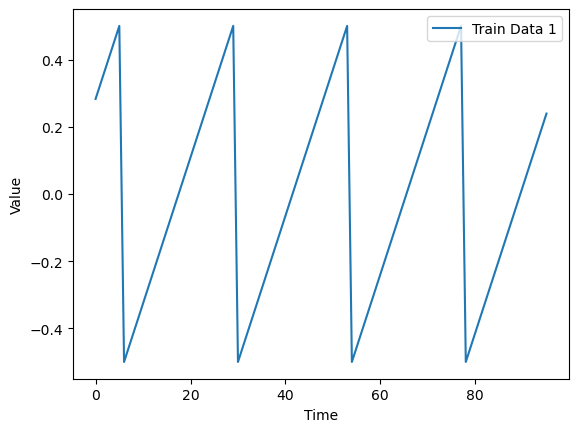

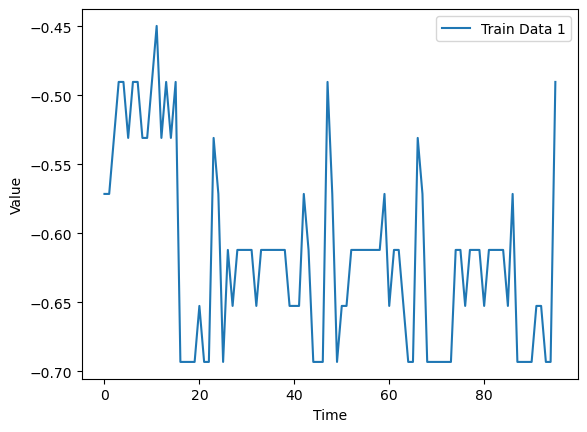

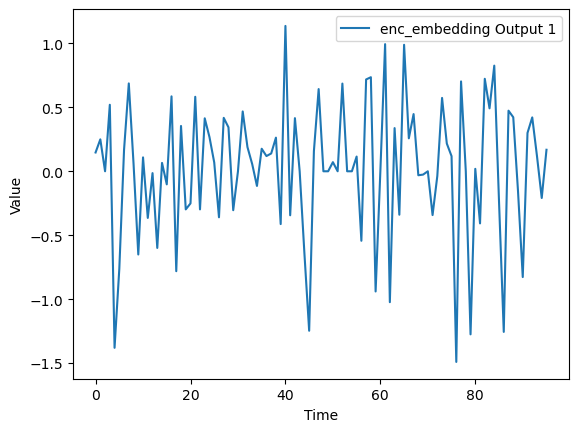

<Figure size 640x480 with 0 Axes>

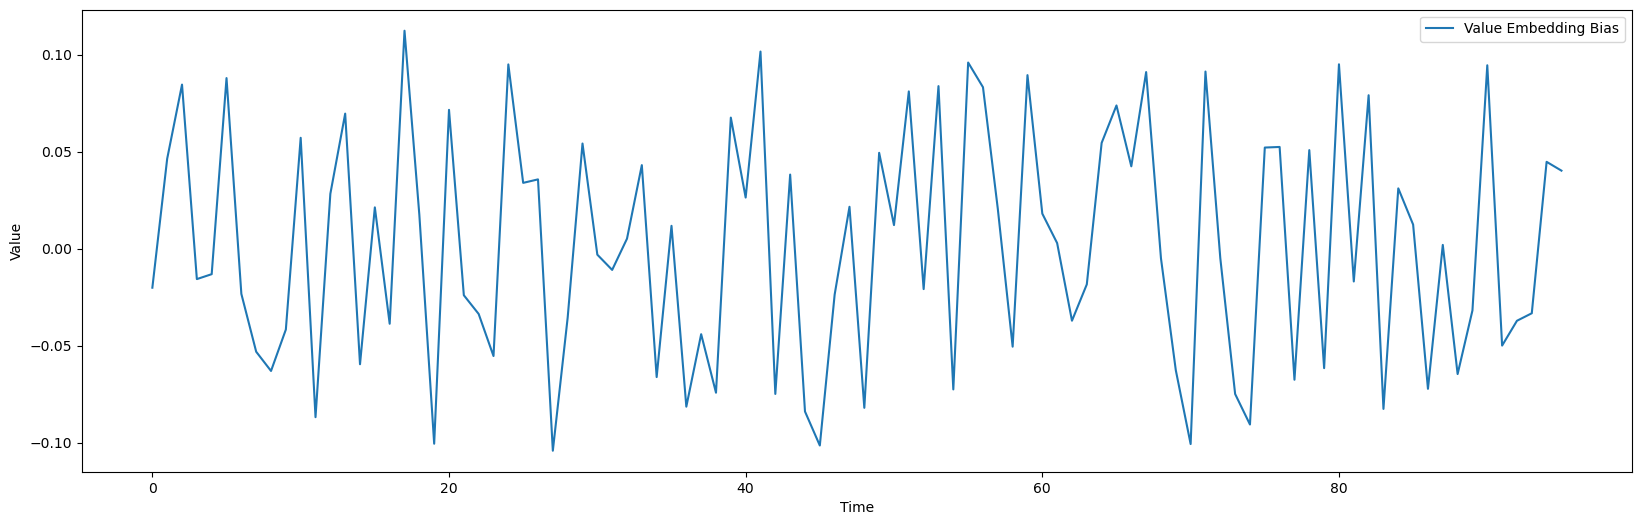

<Figure size 640x480 with 0 Axes>

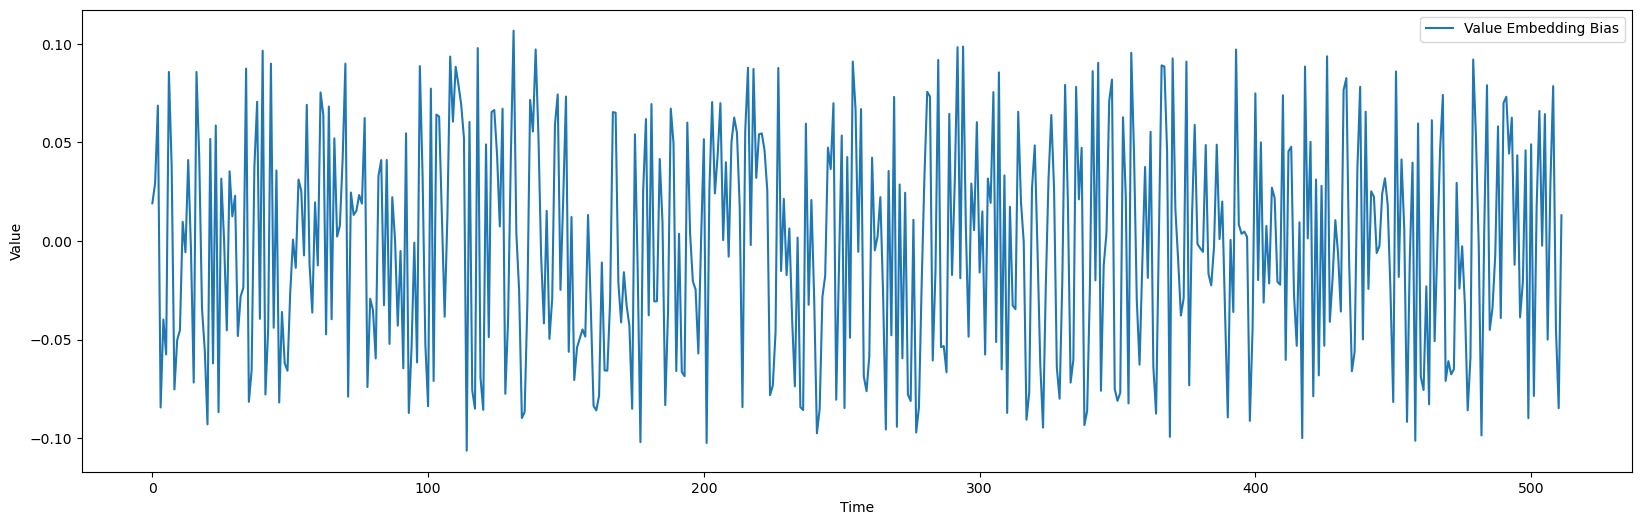

<Figure size 640x480 with 0 Axes>

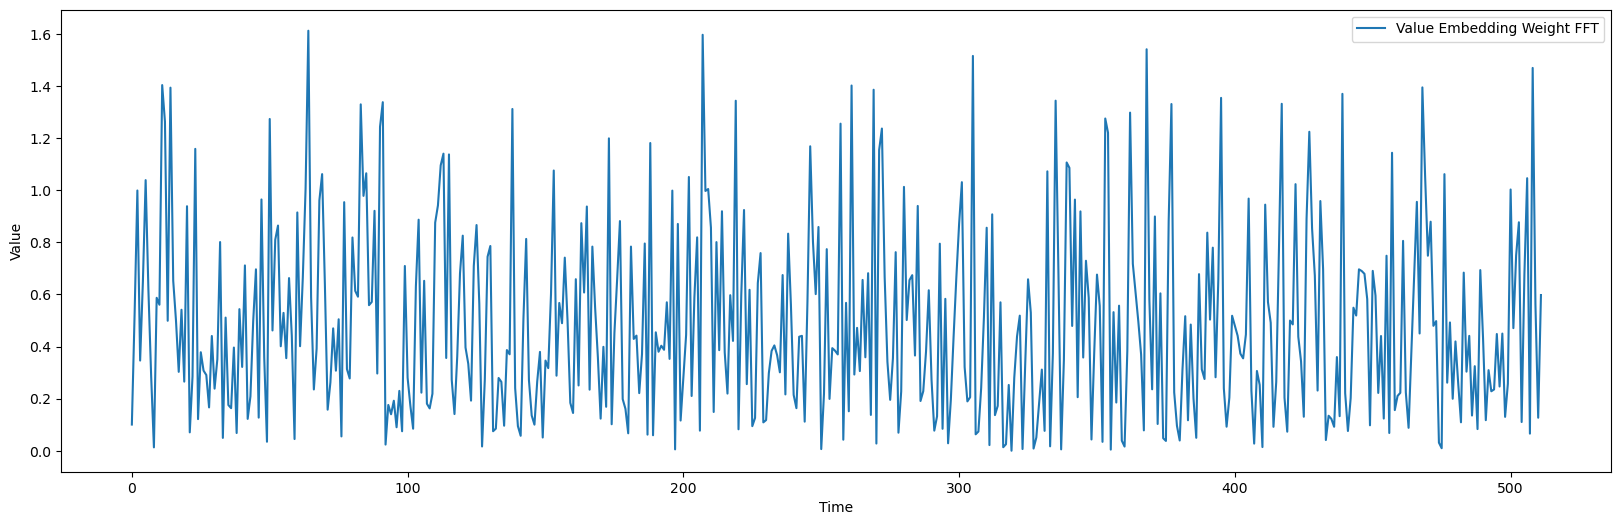

<Figure size 640x480 with 0 Axes>

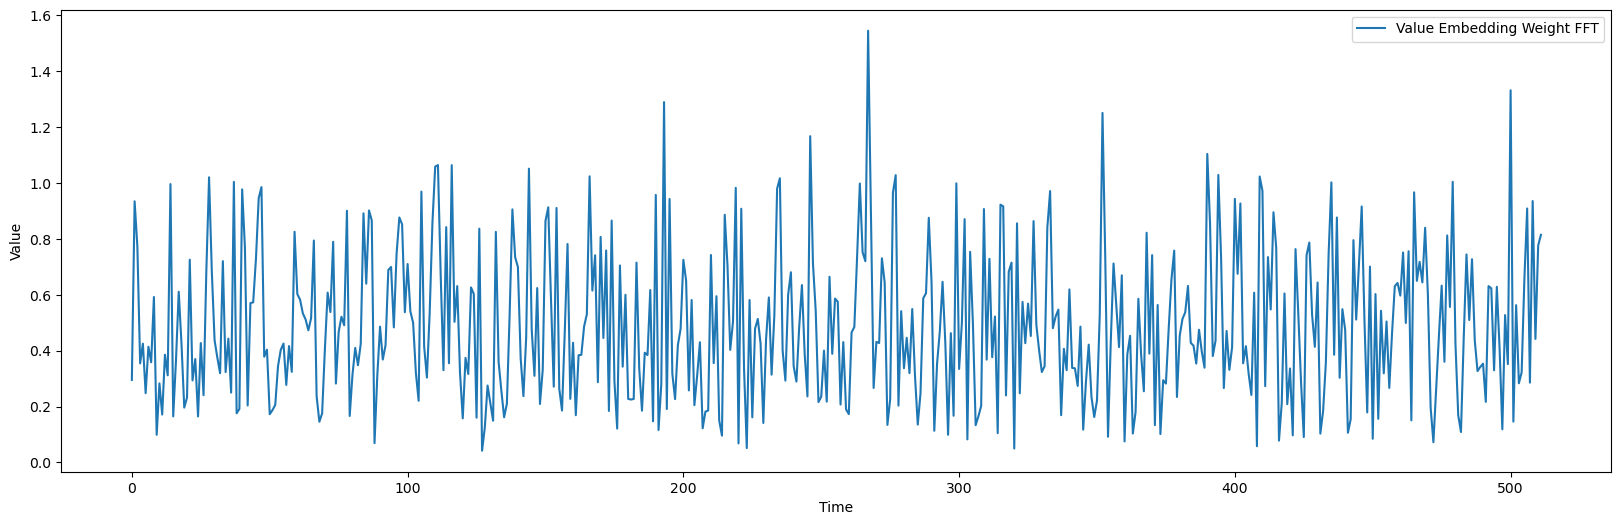

<Figure size 640x480 with 0 Axes>

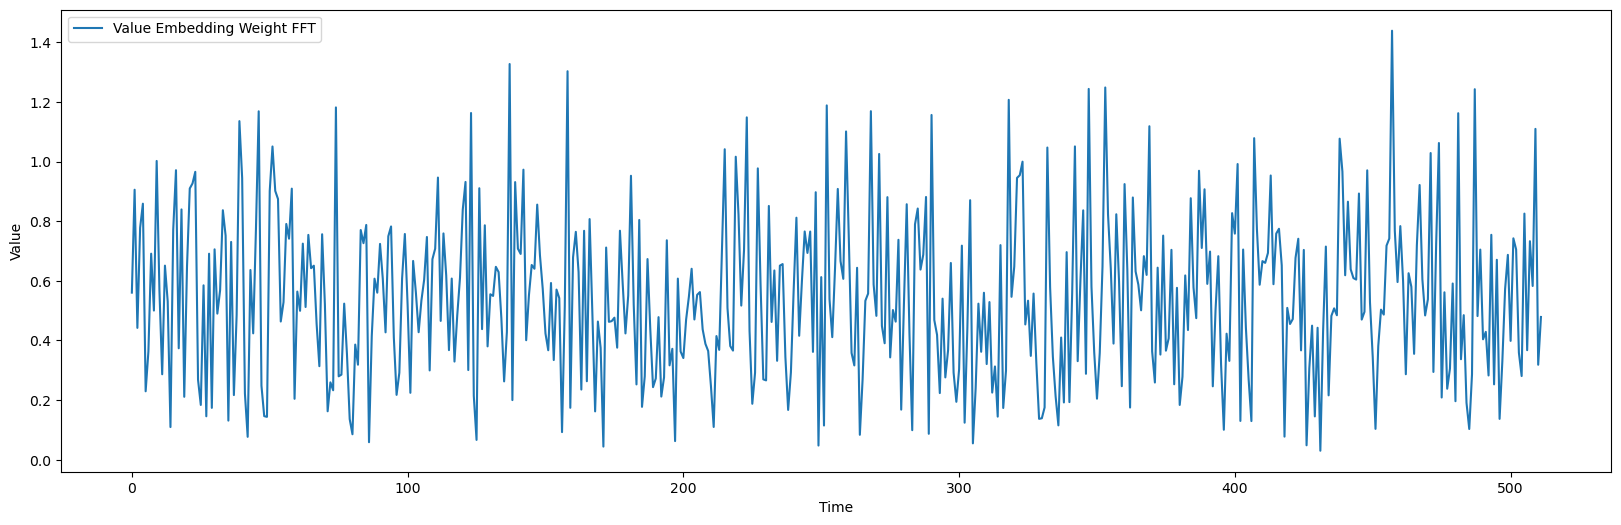

<Figure size 640x480 with 0 Axes>

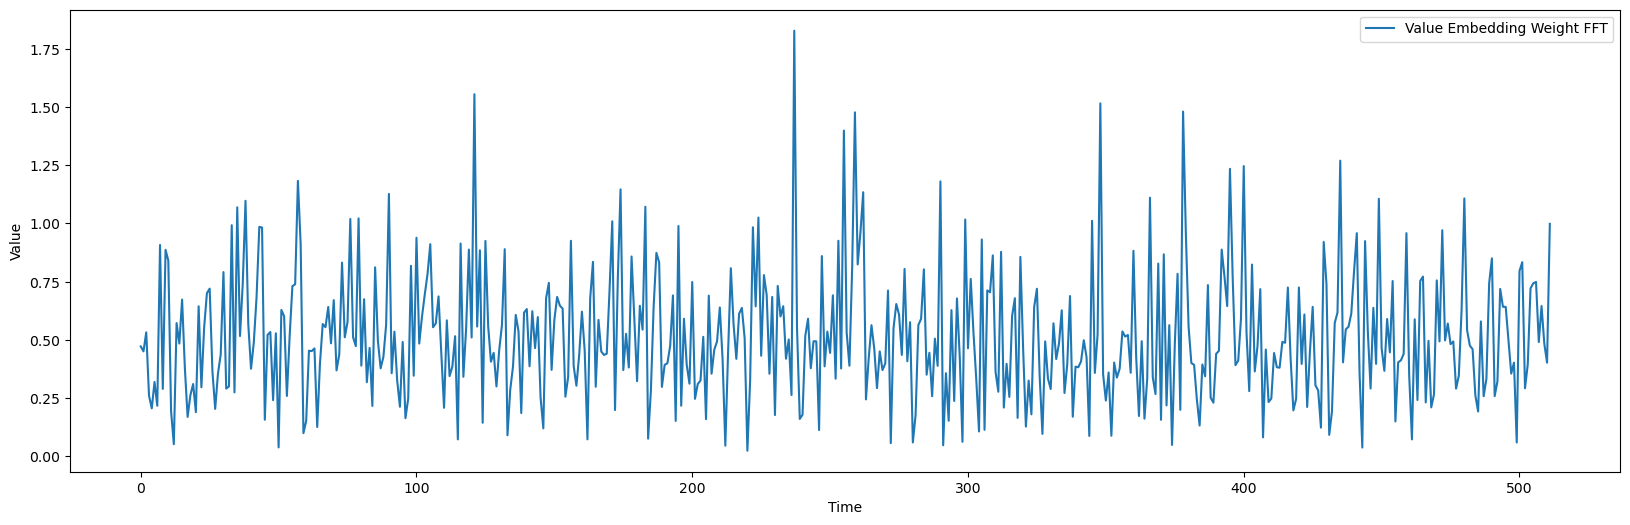

<Figure size 640x480 with 0 Axes>

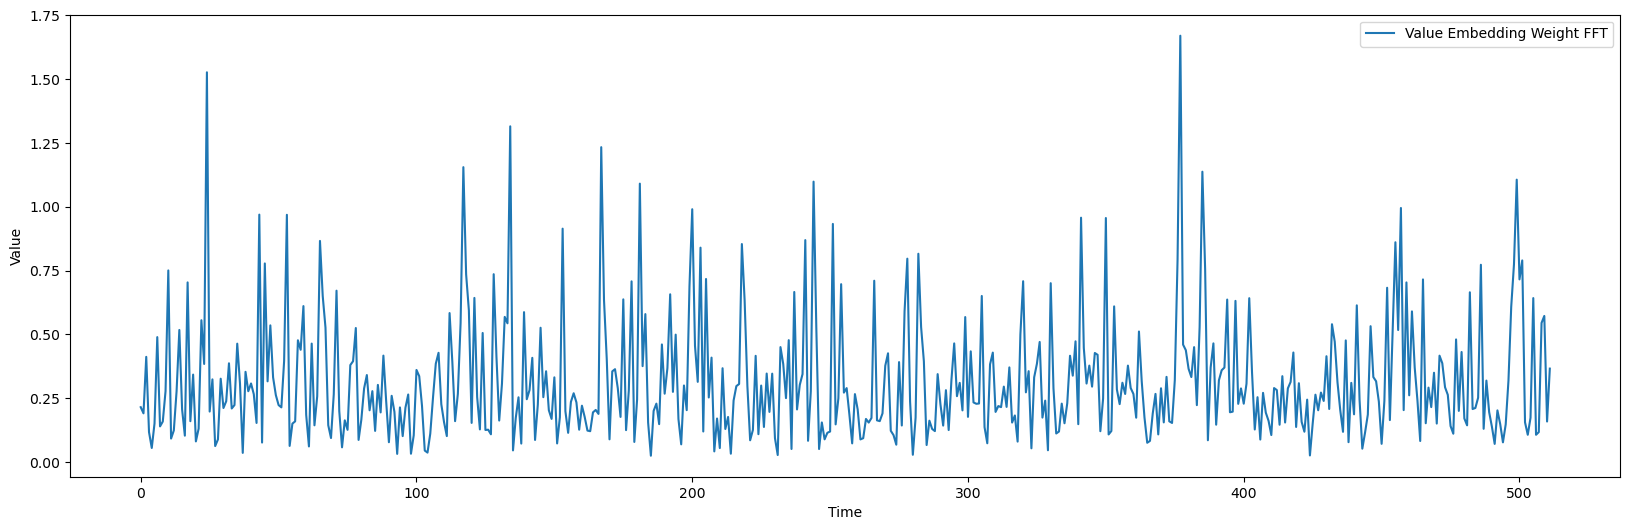

<Figure size 640x480 with 0 Axes>

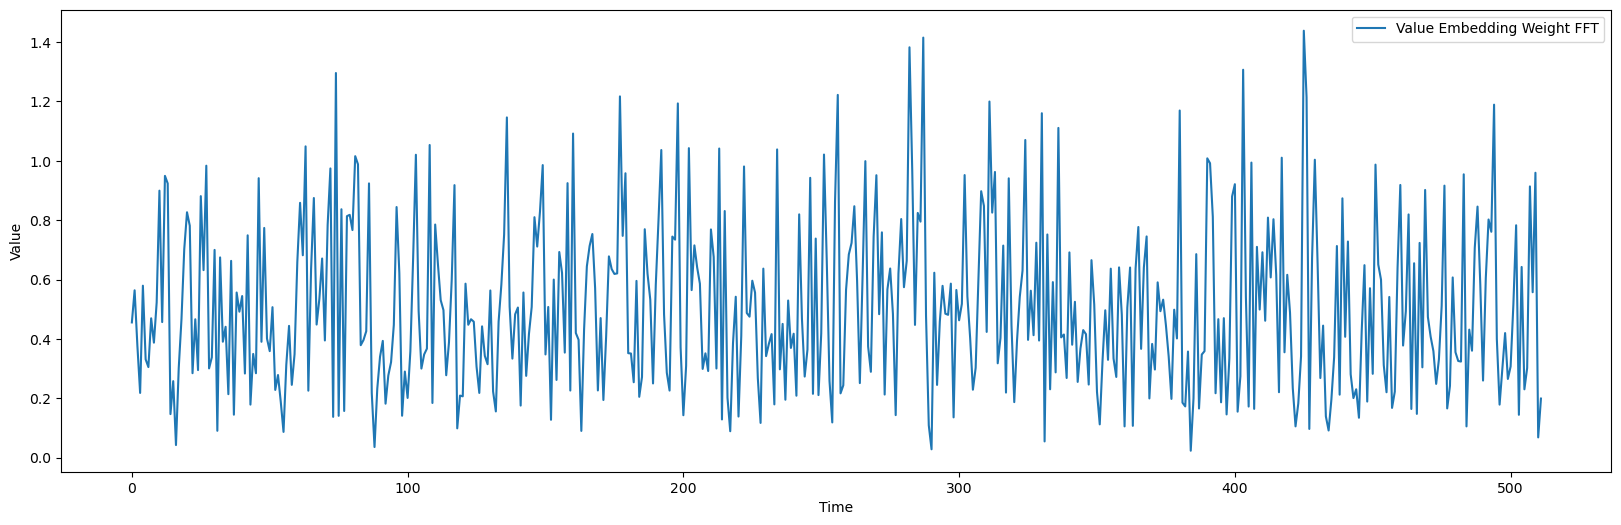

<Figure size 640x480 with 0 Axes>

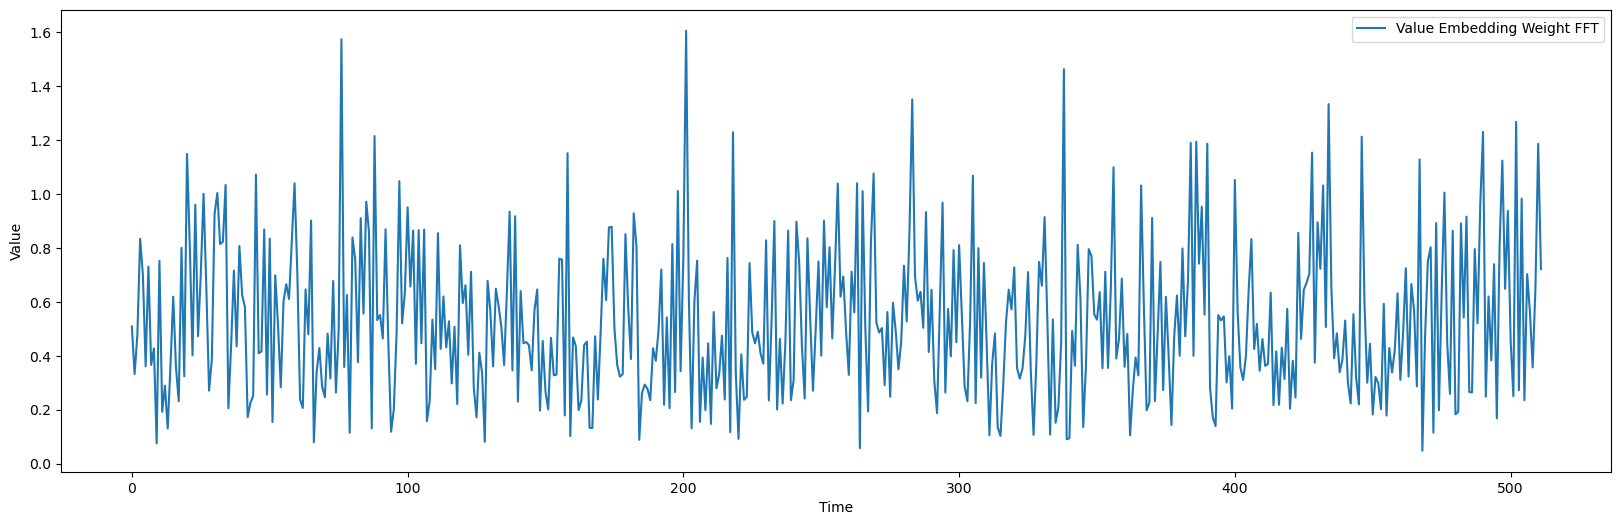

<Figure size 640x480 with 0 Axes>

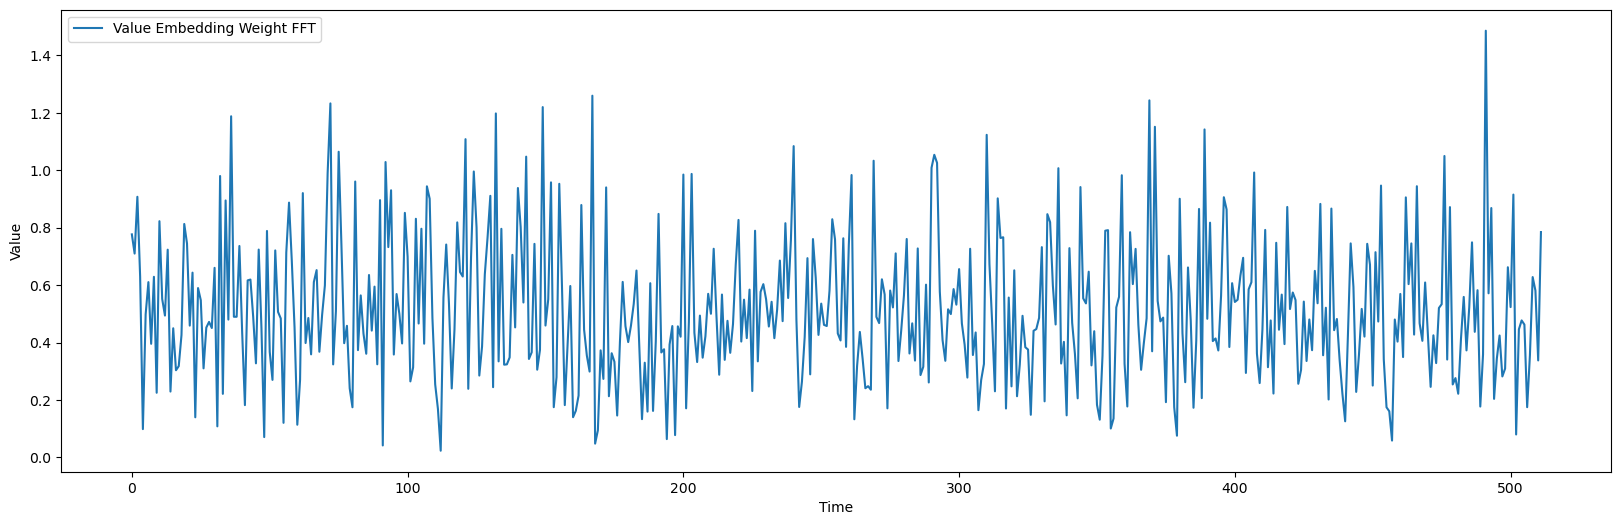

<Figure size 640x480 with 0 Axes>

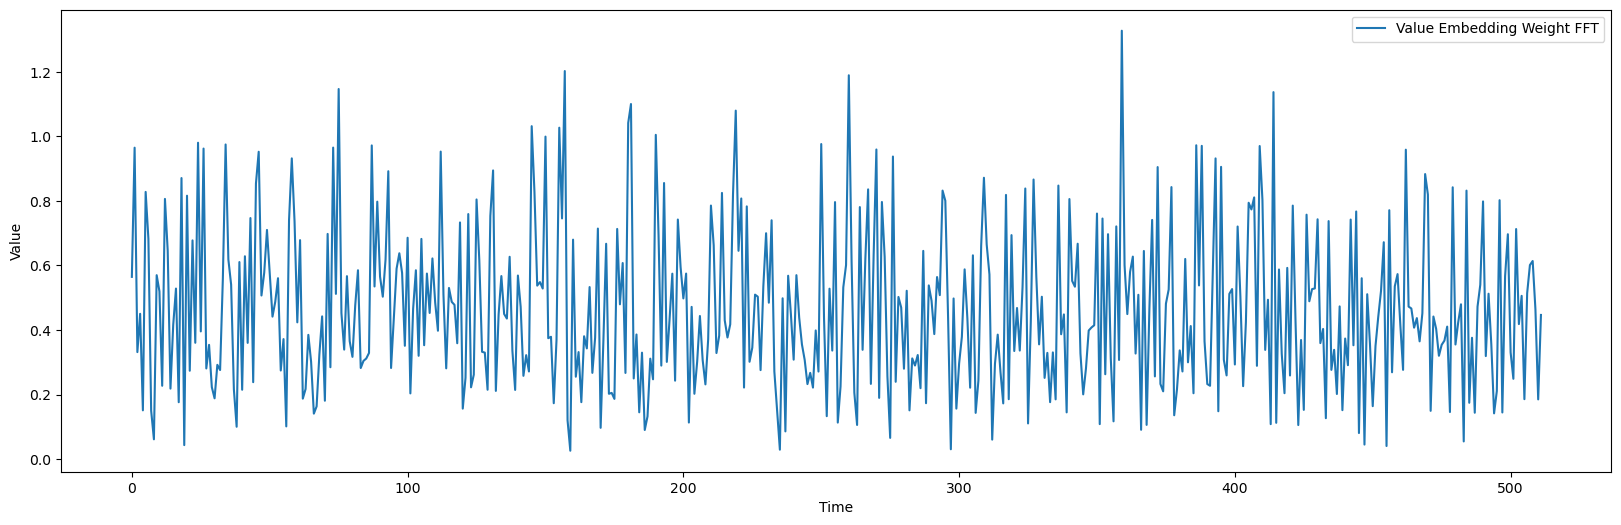

<Figure size 640x480 with 0 Axes>

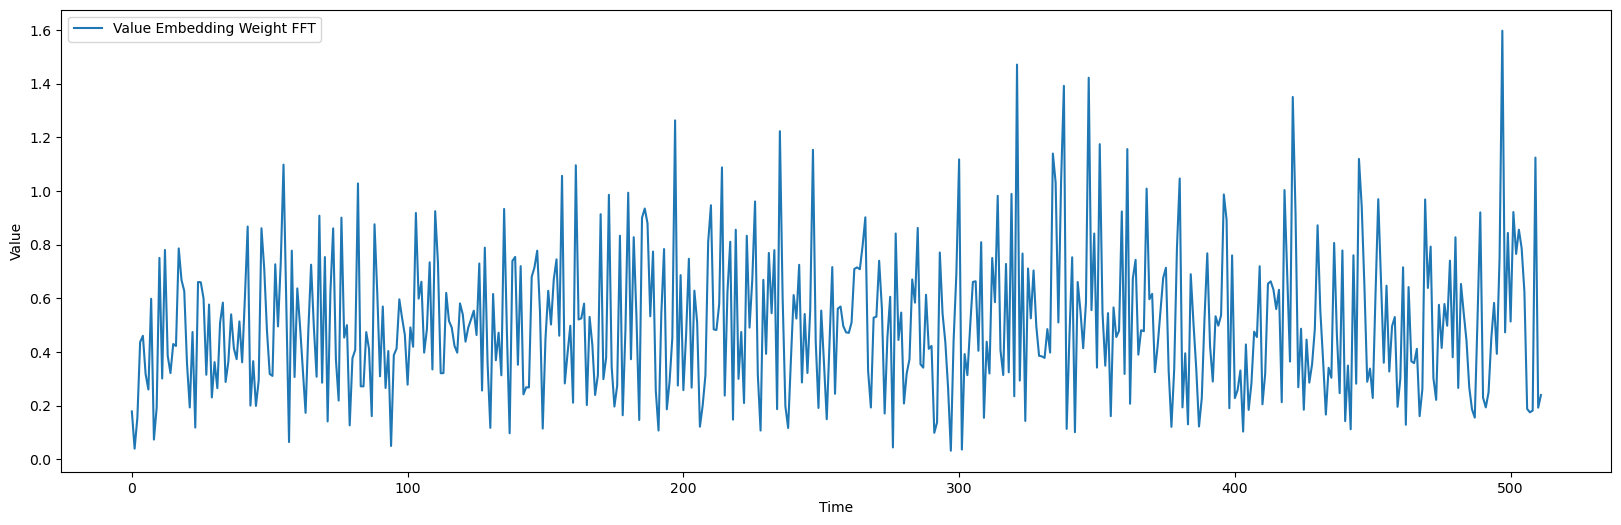

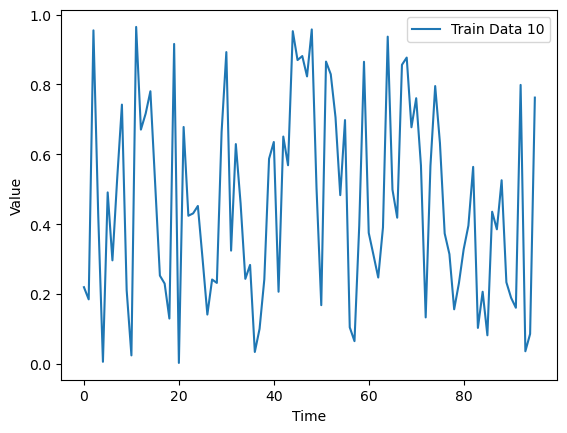

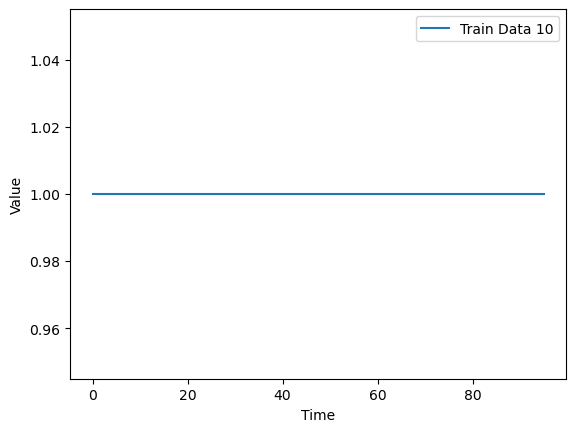

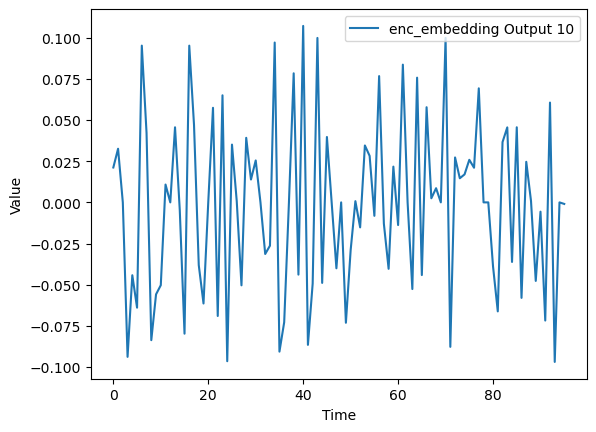

<Figure size 640x480 with 0 Axes>

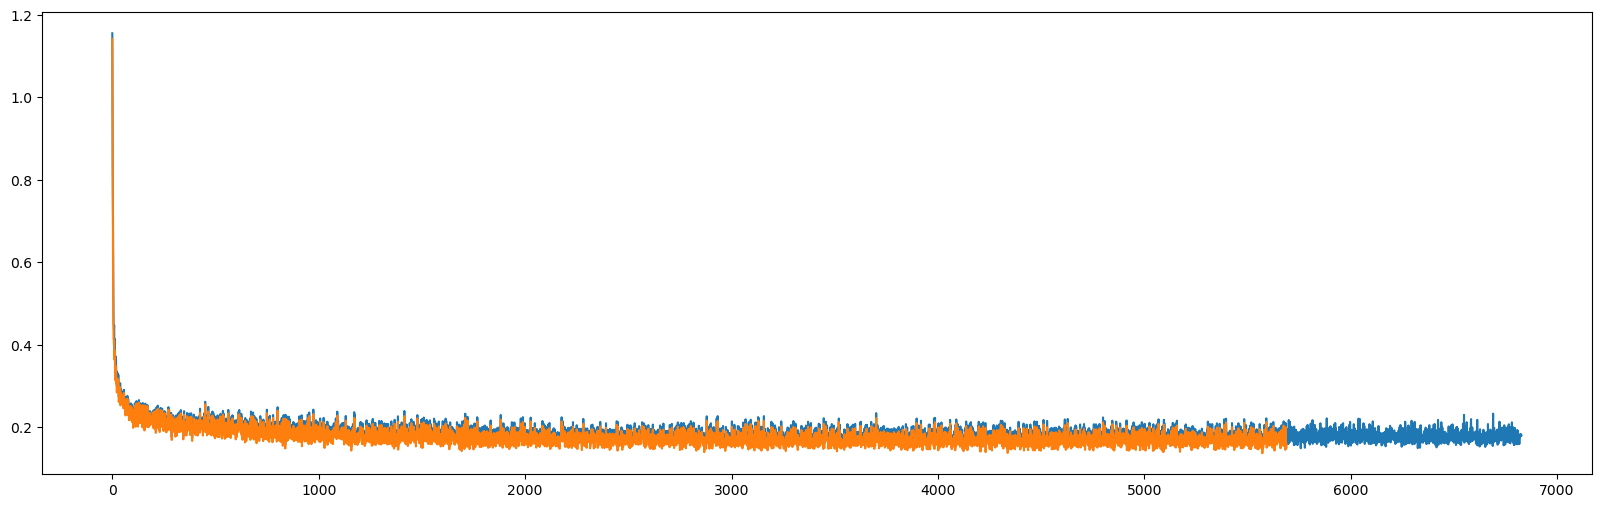

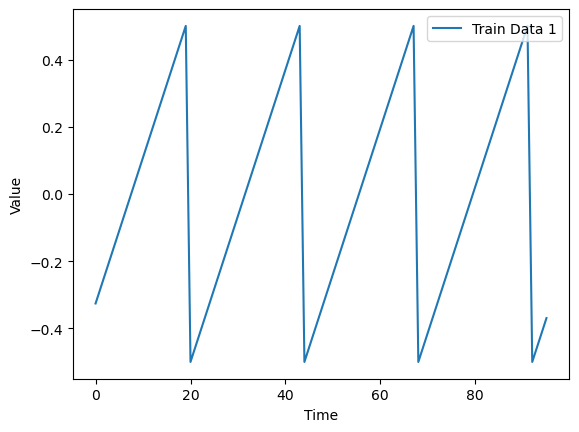

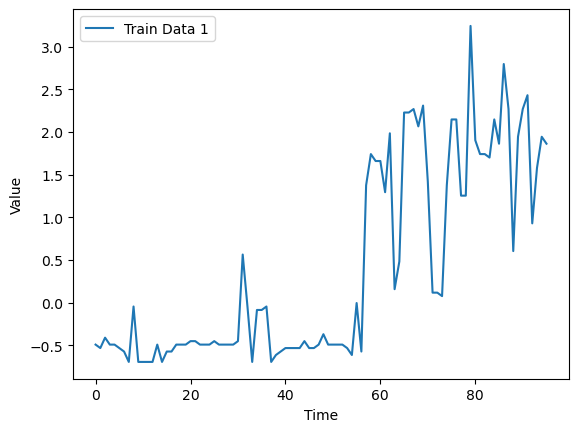

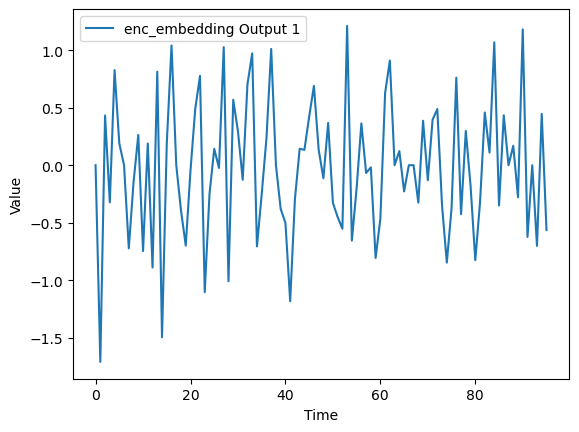

Iteration 1 completed, breaking the loop.


In [13]:
# Get the output of enc_embedding
enc_embedding_input = None
enc_embedding_output = None

# Define a hook function to retrieve the output of the enc_embedding layer
def hook_fn(module, input, output):
    # Store the output in a global variable
    global enc_embedding_output
    global enc_embedding_input
    enc_embedding_input = input
    enc_embedding_output = output
    # return output

# Add the hook to the enc_embedding layer
exp.model.module.enc_embedding.register_forward_hook(hook_fn)

# Plot the different train data
for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(train_loader):
    batch_x = batch_x.float().to(exp.device)
    batch_y = batch_y.float().to(exp.device)
    if 'PEMS' in exp.args.data or 'Solar' in exp.args.data:
        batch_x_mark = None
        batch_y_mark = None
    else:
        batch_x_mark = batch_x_mark.float().to(exp.device)
        batch_y_mark = batch_y_mark.float().to(exp.device)

    # decoder input
    dec_inp = torch.zeros_like(batch_y[:, -exp.args.pred_len:, :]).float()
    dec_inp = torch.cat([batch_y[:, :exp.args.label_len, :], dec_inp], dim=1).float().to(exp.device)

    # encoder - decoder
    if exp.args.output_attention:
        outputs = exp.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)[0]
    else:
        outputs = exp.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)

    f_dim = -1 if exp.args.features == 'MS' else 0
    # outputs = outputs[:, -exp.args.pred_len:, f_dim:]
    # batch_y = batch_y[:, -exp.args.pred_len:, f_dim:].to(exp.device)

    # 打印输出和embedding的形状
    print(f'input Shape: {batch_x.shape}')
    print(f'batch_x_mark Shape: {batch_x_mark.shape}')
    print(f'Enc Embedding input Shape: {enc_embedding_input[0].shape, enc_embedding_input[1].shape}')
    print(f'Enc Embedding Output Shape: {enc_embedding_output.shape}')

    channel = 0

    # Plot the input data
    plt.figure()
    plt.plot(batch_x_mark[0, :, channel].cpu().numpy().flatten(), label=f'Train Data {i+1}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    # Plot the input data
    plt.figure()
    plt.plot(batch_x[0, :, channel].cpu().numpy().flatten(), label=f'Train Data {i+1}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    # exp.model.module.enc_embedding(batch_x)

    # Plot the output of enc_embedding
    plt.figure()
    plt.plot(enc_embedding_output[0, channel, :96].detach().cpu().numpy().flatten(), label=f'enc_embedding Output {i+1}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()
    # 添加调试信息
    print(f'Iteration {i+1} completed, breaking the loop.')
    break


Value Embedding Parameters:
weight torch.Size([512, 96]) Parameter containing:
tensor([[-0.0202,  0.0464,  0.0846,  ..., -0.0333,  0.0447,  0.0402],
        [ 0.0632, -0.0811,  0.0729,  ..., -0.0968, -0.0036, -0.0283],
        [ 0.0052, -0.0446,  0.0227,  ..., -0.1005,  0.0194,  0.0609],
        ...,
        [ 0.0824,  0.0917,  0.0178,  ...,  0.0028,  0.0587,  0.0335],
        [-0.0411, -0.0179, -0.0275,  ...,  0.0080, -0.0564,  0.0804],
        [-0.0588,  0.0260, -0.0676,  ..., -0.0946,  0.0736,  0.0628]],
       device='cuda:0', requires_grad=True)
bias torch.Size([512]) Parameter containing:
tensor([ 0.0191,  0.0293,  0.0687, -0.0845, -0.0398, -0.0576,  0.0857,  0.0379,
        -0.0753, -0.0503, -0.0453,  0.0097, -0.0057,  0.0411, -0.0042, -0.0718,
         0.0857,  0.0424, -0.0343, -0.0553, -0.0930,  0.0517, -0.0621,  0.0585,
        -0.0868,  0.0316,  0.0007, -0.0454,  0.0353,  0.0125,  0.0229, -0.0482,
        -0.0282, -0.0237,  0.0874, -0.0816, -0.0655,  0.0376,  0.0706, -0.0395

<Figure size 640x480 with 0 Axes>

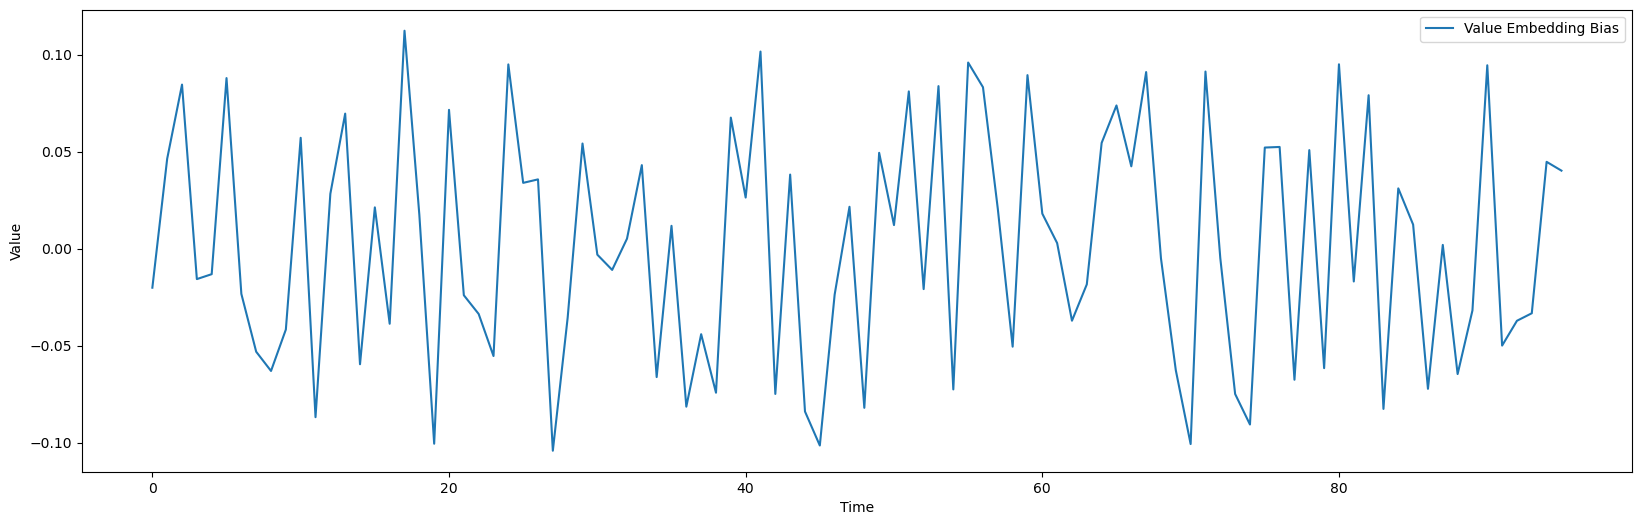

<Figure size 640x480 with 0 Axes>

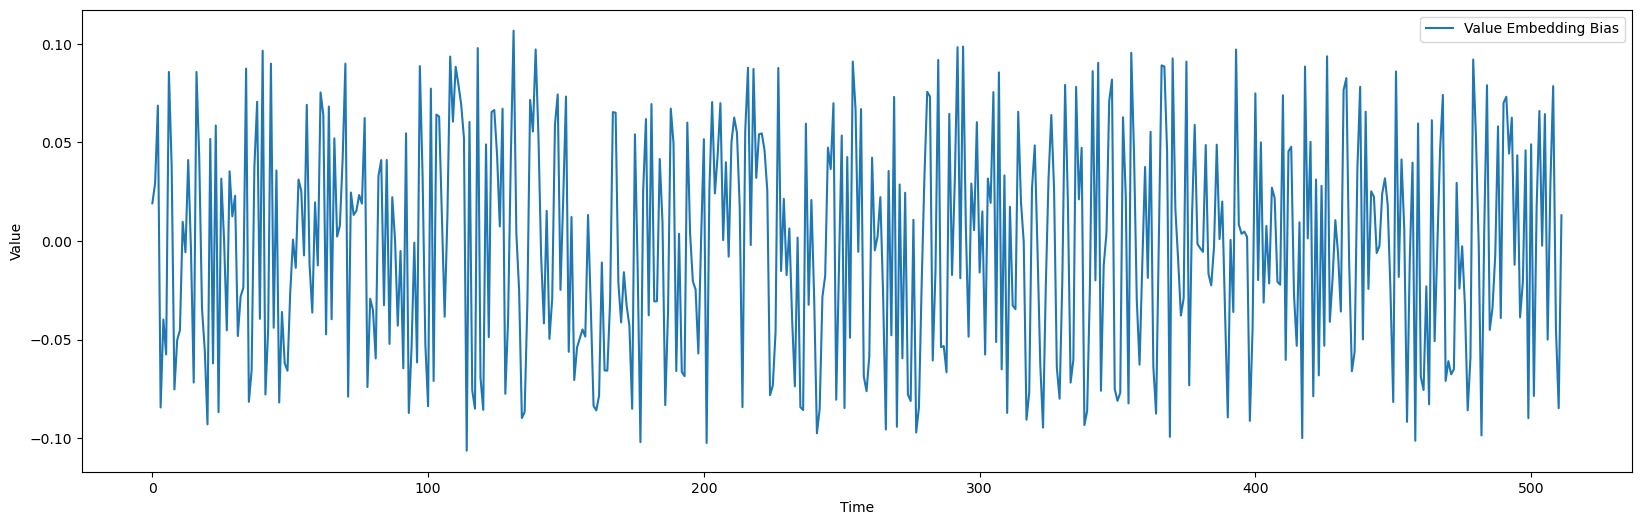

In [14]:
# 给出exp.model.module.enc_embedding.value_embedding的参数
print('Value Embedding Parameters:')
for name, param in exp.model.module.enc_embedding.value_embedding.named_parameters():
    print(name, param.shape, param)


# 画出bias
plt.figure()
# 调整图像大小
plt.figure(figsize=(20, 6))
plt.plot(exp.model.module.enc_embedding.value_embedding.weight[0, :].detach().cpu().numpy().flatten(), label='Value Embedding Bias')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

# 画出bias
plt.figure()
# 调整图像大小
plt.figure(figsize=(20, 6))
plt.plot(exp.model.module.enc_embedding.value_embedding.bias.detach().cpu().numpy().flatten(), label='Value Embedding Bias')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()


<Figure size 640x480 with 0 Axes>

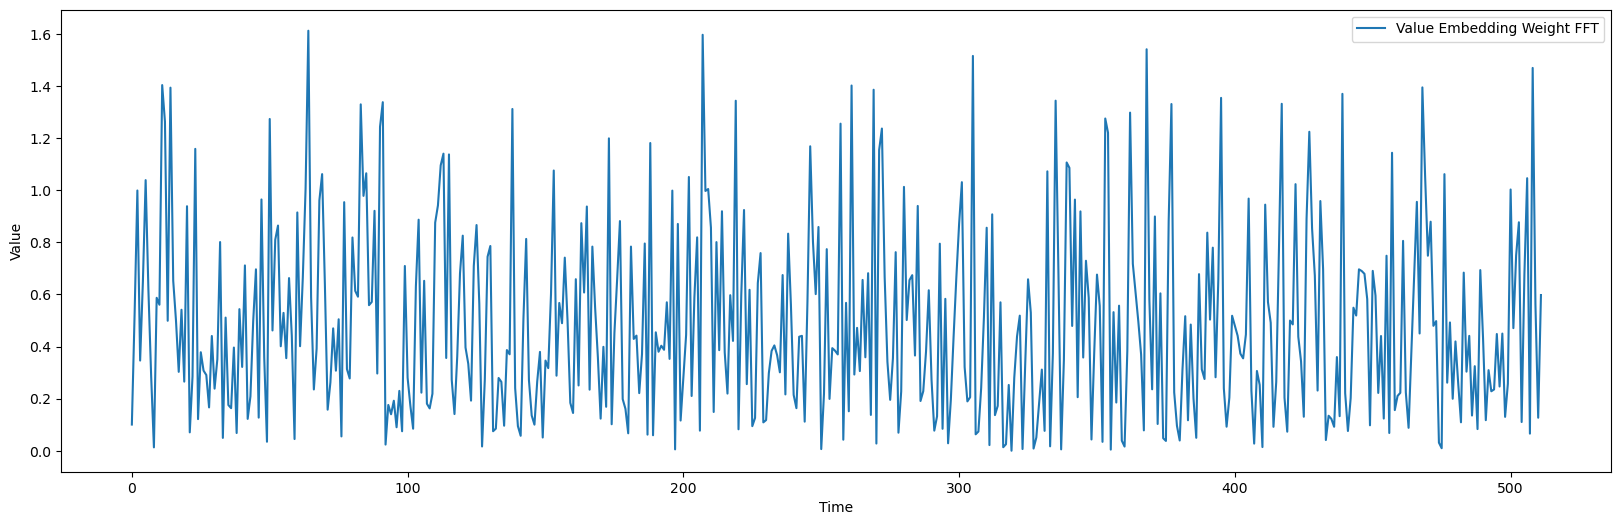

<Figure size 640x480 with 0 Axes>

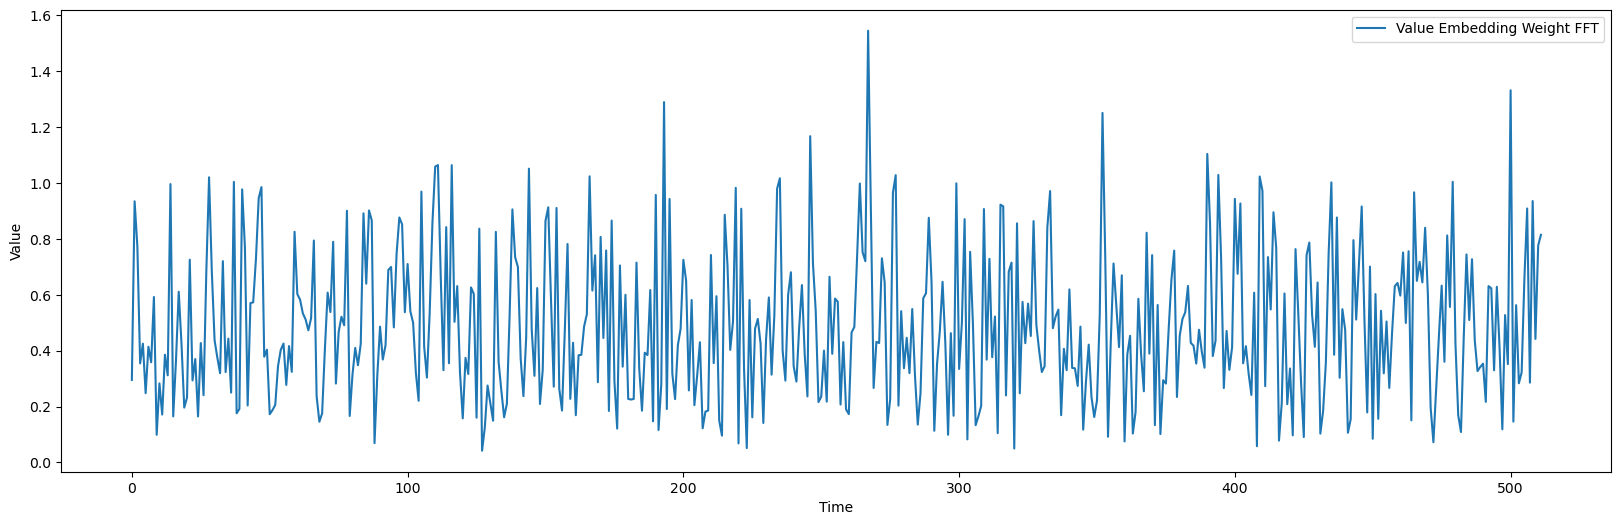

<Figure size 640x480 with 0 Axes>

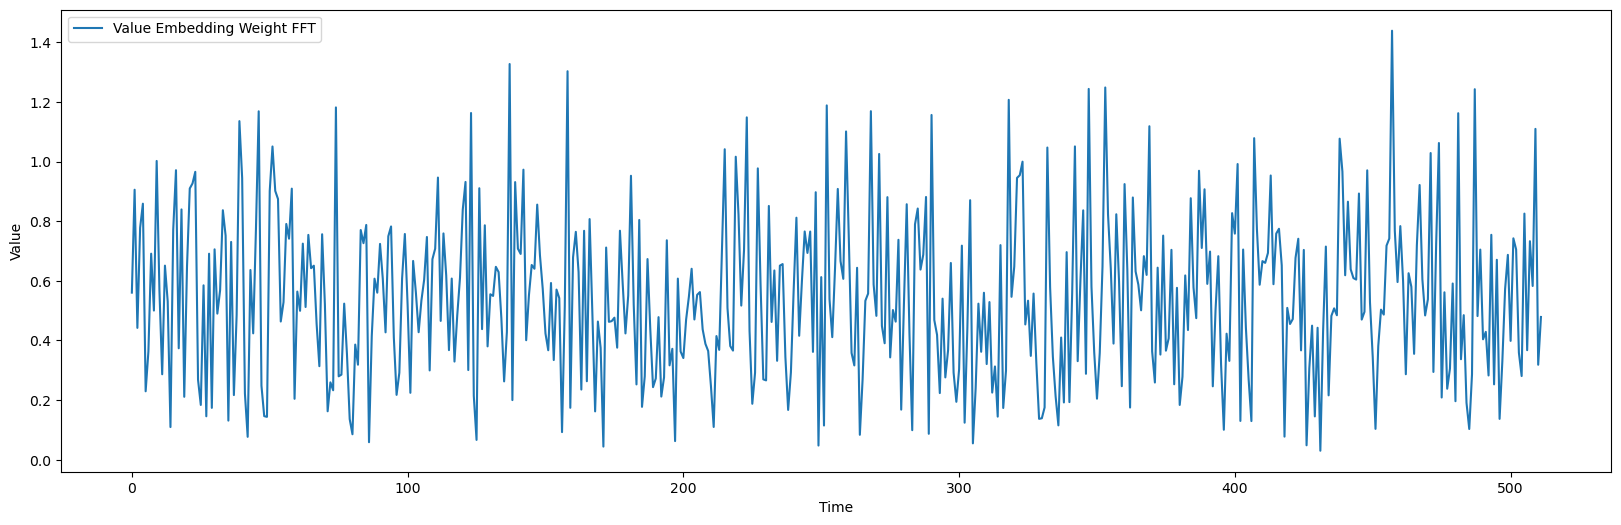

<Figure size 640x480 with 0 Axes>

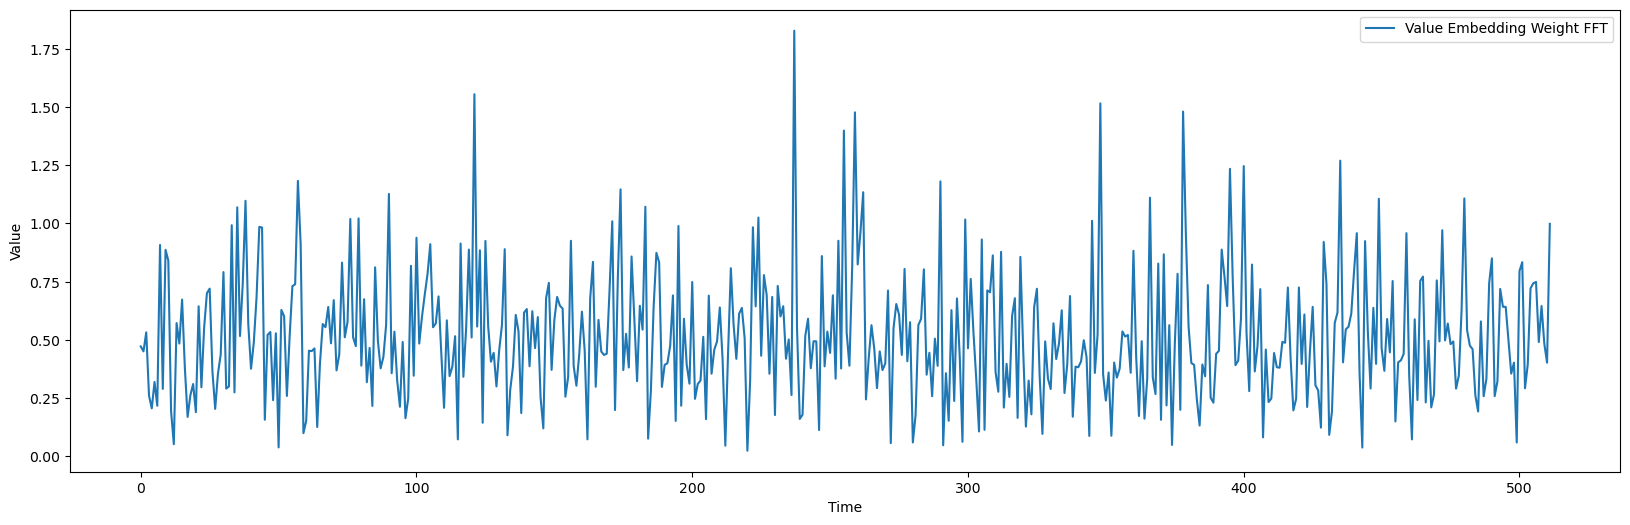

<Figure size 640x480 with 0 Axes>

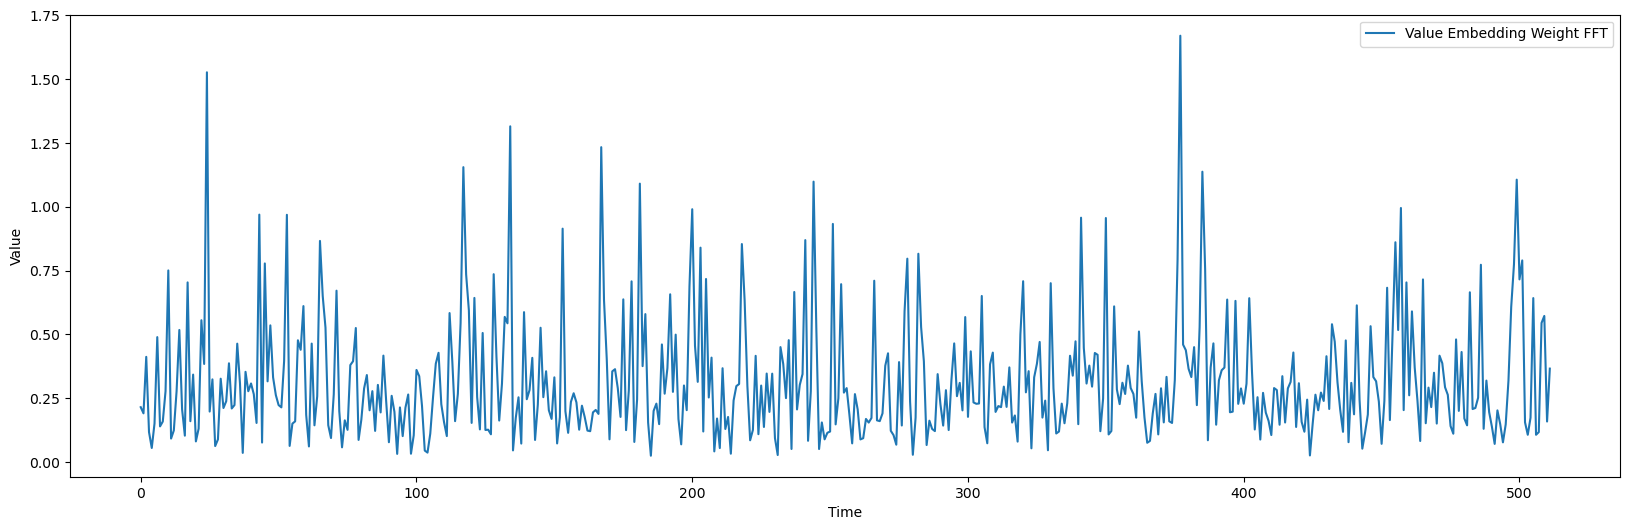

<Figure size 640x480 with 0 Axes>

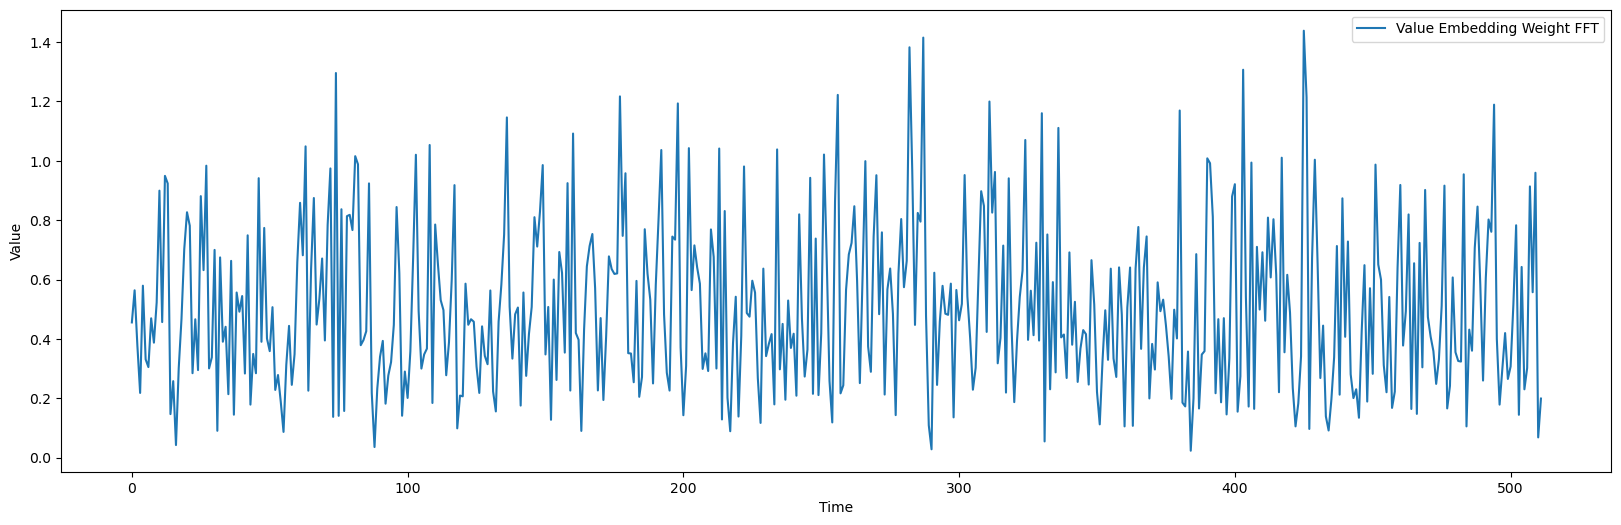

<Figure size 640x480 with 0 Axes>

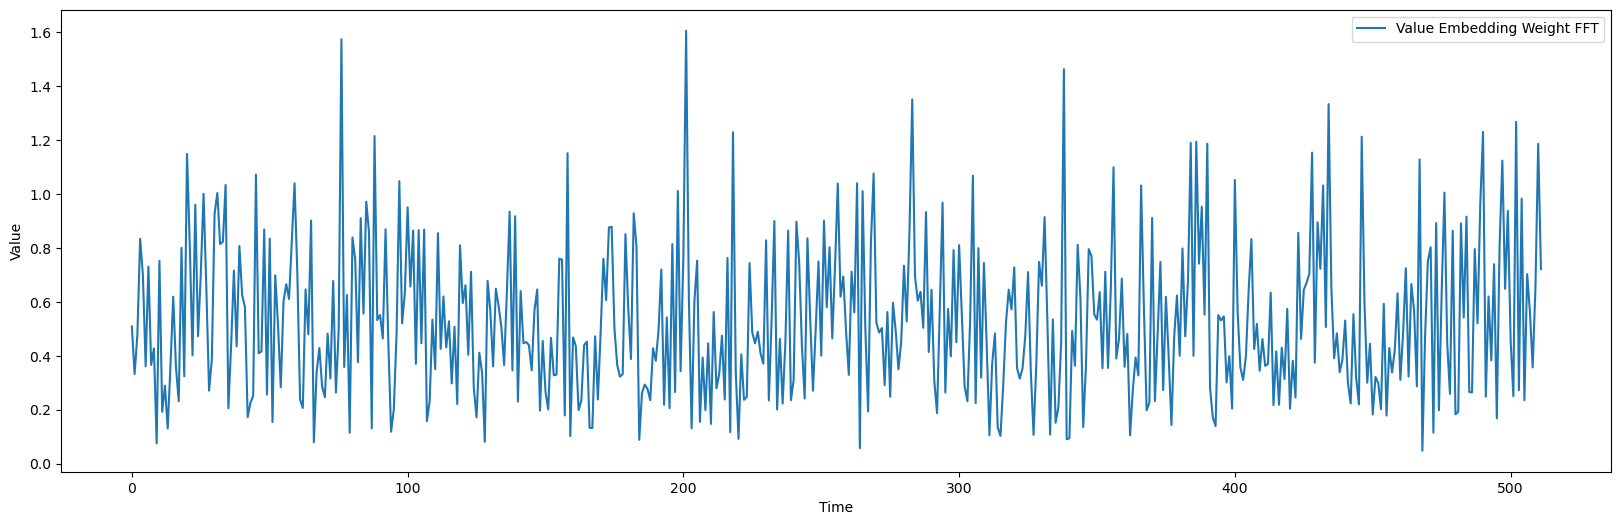

<Figure size 640x480 with 0 Axes>

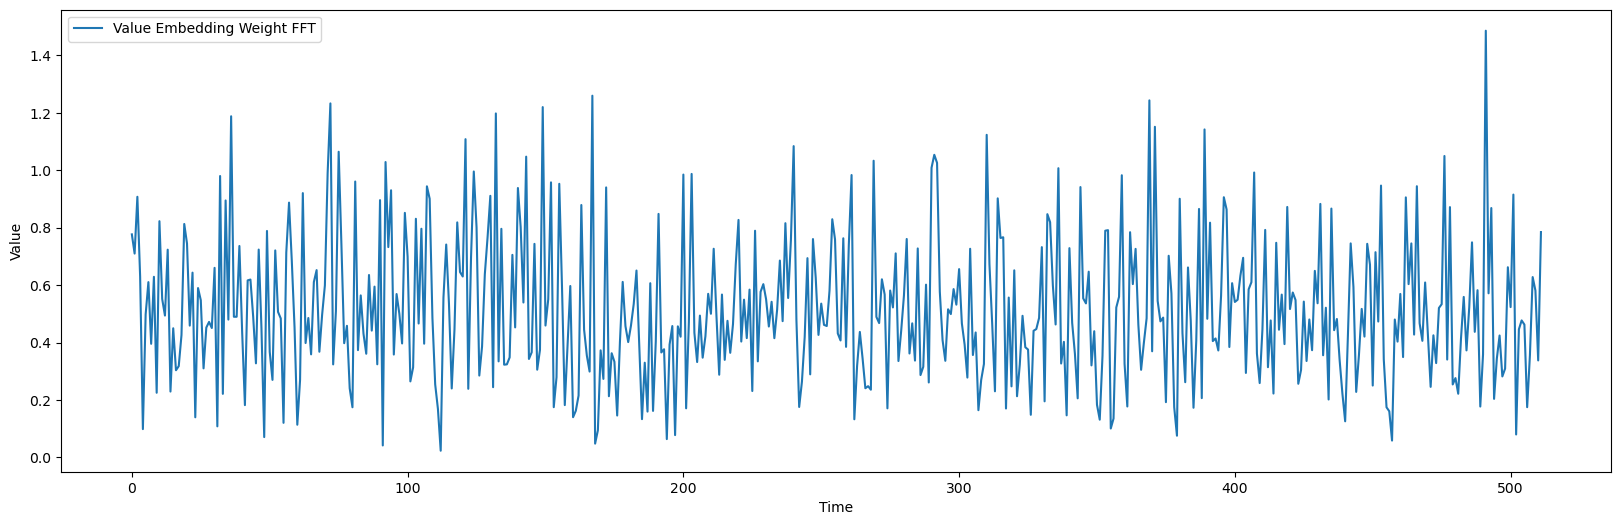

<Figure size 640x480 with 0 Axes>

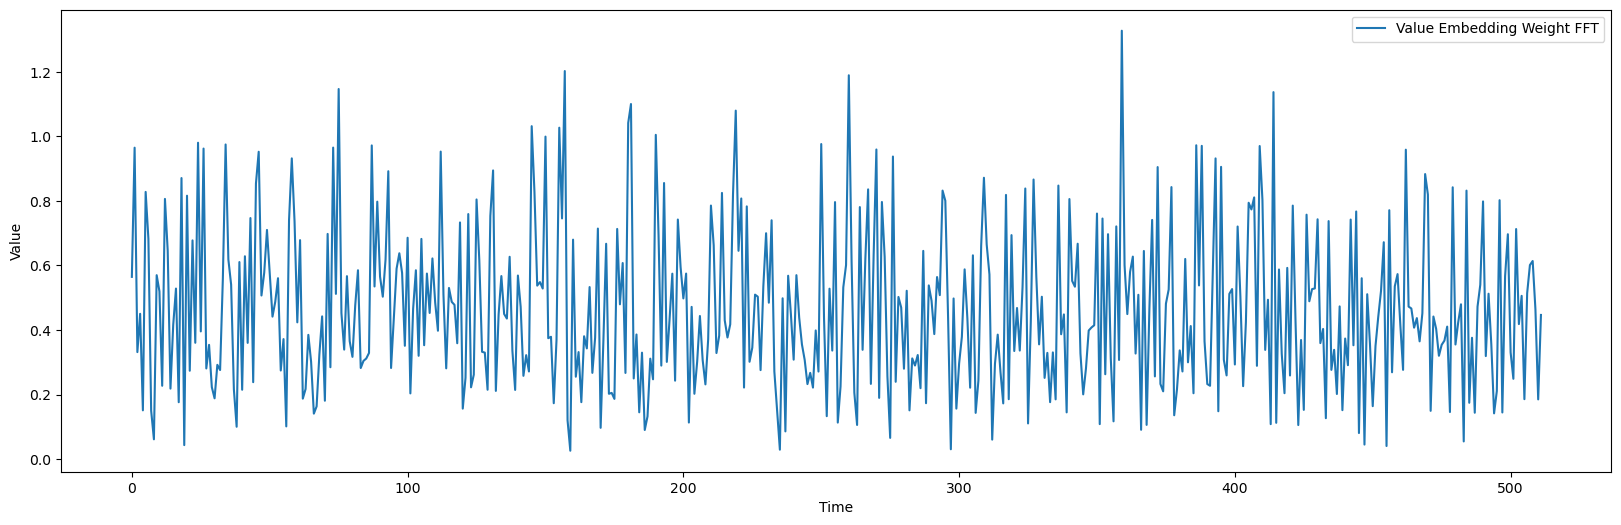

<Figure size 640x480 with 0 Axes>

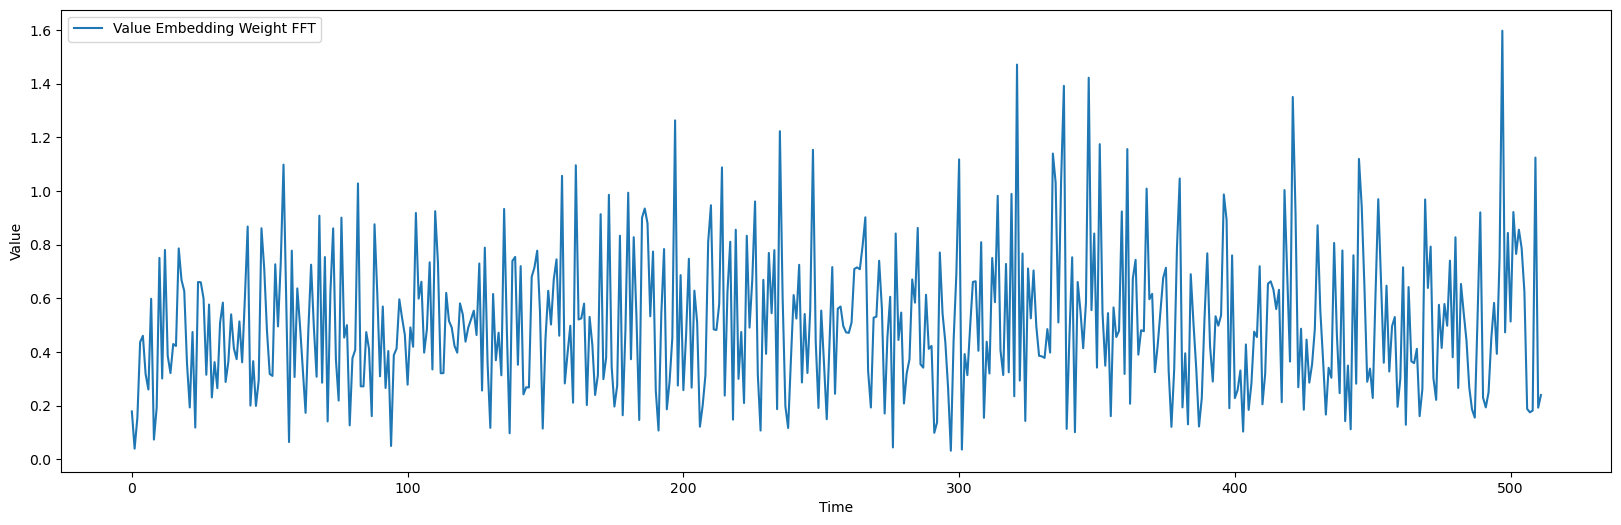

In [15]:
# 计算并画出weight每一行的fft
fft = np.fft.fft(exp.model.module.enc_embedding.value_embedding.weight.detach().cpu().numpy())
fft = np.abs(fft)
for i in range(10):
    plt.figure()
    # 调整图像大小
    plt.figure(figsize=(20, 6))
    plt.plot(fft[:, i].flatten(), label='Value Embedding Weight FFT')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [16]:
from scipy.stats import shapiro, kstest, norm

# Extract the weights from the value embedding layer
weights = exp.model.module.enc_embedding.value_embedding.weight.detach().cpu().numpy().flatten()

# Perform Shapiro-Wilk test
shapiro_test = shapiro(weights)
print(f'Shapiro-Wilk Test: Statistic={shapiro_test.statistic}, p-value={shapiro_test.pvalue}')

# Perform Kolmogorov-Smirnov test
ks_test = kstest(weights, 'norm', args=(weights.mean(), weights.std()))
print(f'Kolmogorov-Smirnov Test: Statistic={ks_test.statistic}, p-value={ks_test.pvalue}')


Shapiro-Wilk Test: Statistic=0.9605899390561164, p-value=1.2900551502672383e-74
Kolmogorov-Smirnov Test: Statistic=0.05625879628702657, p-value=1.1612598551695743e-135


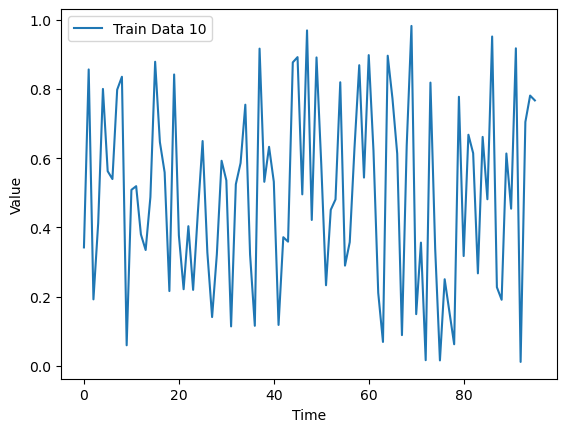

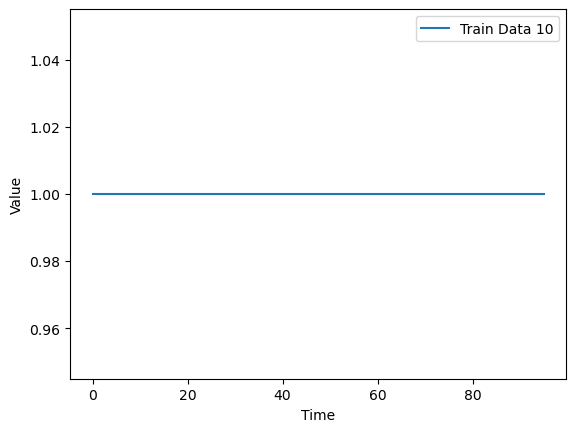

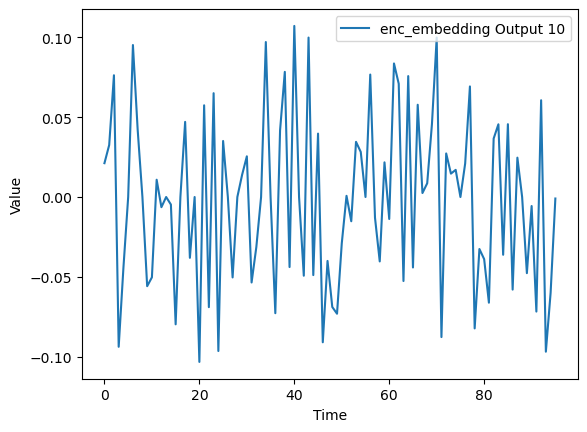

Iteration 10 completed, breaking the loop.


In [17]:
# 生成一个[1, 96, 321]和一个[1, 96, 4]的随机张量
x = torch.rand(1, 96, 321)
x = torch.ones(1, 96, 321)
x_mark = torch.rand(1, 96, 4)

outputs = exp.model(x, x_mark, x, x_mark)

# 画出embedding

channel = 0

# Plot the input data
plt.figure()
plt.plot(x_mark[0, :, channel].cpu().numpy().flatten(), label=f'Train Data {i+1}')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

# Plot the input data
plt.figure()
plt.plot(x[0, :, channel].cpu().numpy().flatten(), label=f'Train Data {i+1}')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

# exp.model.module.enc_embedding(batch_x)

# Plot the output of enc_embedding
plt.figure()
plt.plot(enc_embedding_output[0, channel, :96].detach().cpu().numpy().flatten(), label=f'enc_embedding Output {i+1}')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()
# 添加调试信息
print(f'Iteration {i+1} completed, breaking the loop.')



ValueError: operands could not be broadcast together with shapes (6828,) (5690,) 

<Figure size 640x480 with 0 Axes>

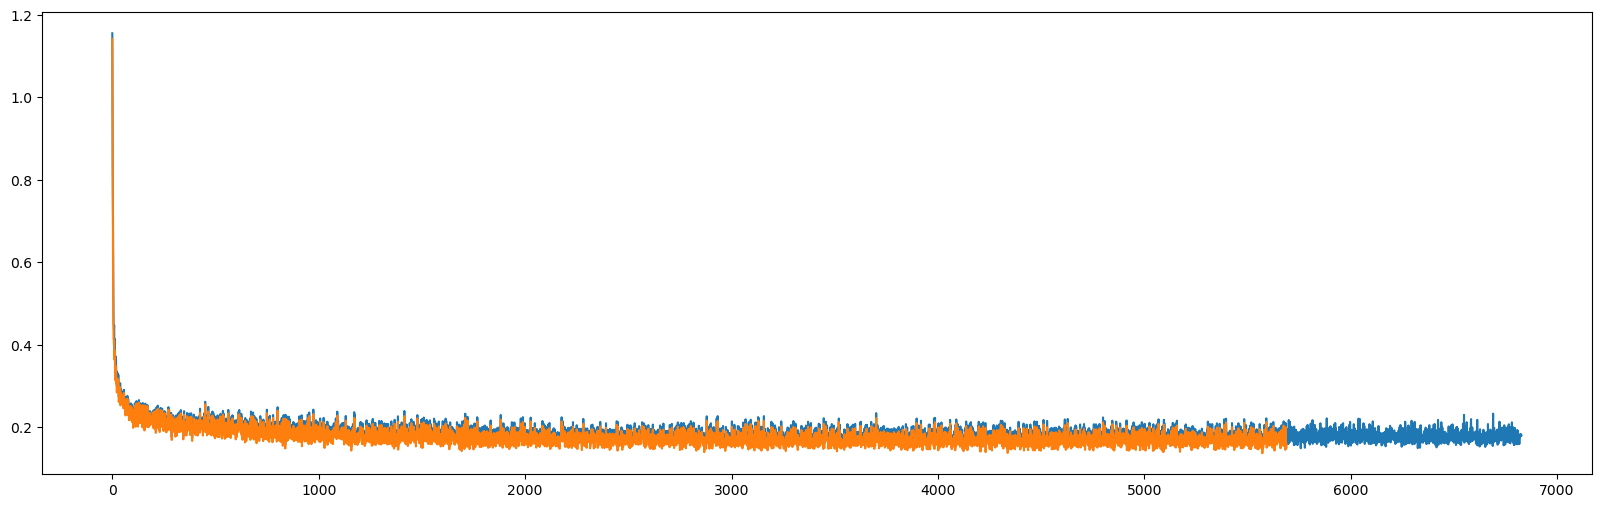

In [18]:
from torch.utils.tensorboard import SummaryWriter
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# 读取tensorboard日志
path1 = r"/home/liangzida/workspace/iTransformer/output/tensorboard/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_0/1729563165.1284842/events.out.tfevents.1729563165.front-core-II.20133.0"
path2 = r"/home/liangzida/workspace/iTransformer/output/tensorboard/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_0/1729490193.9059613/events.out.tfevents.1729490193.front-core-II.7037.0"
path3 = r"/home/liangzida/workspace/iTransformer/output/tensorboard/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_0/no_embedding/1729580297.1012886/events.out.tfevents.1729580297.front-core-II.17280.0"
path4 = r"/home/liangzida/workspace/iTransformer/output/tensorboard/events.out.tfevents.1729488093.front-core-II.40941.0"

def get_loss(path):
    # Load the tensorboard log
    event_acc = EventAccumulator(path)
    event_acc.Reload()

    # Extract scalar data
    scalar_data = {}
    for tag in event_acc.Tags()['scalars']:
        scalar_data[tag] = []
        events = event_acc.Scalars(tag)
        for event in events:
            scalar_data[tag].append((event.step, event.value))

    # Convert to numpy arrays
    scalar_data_np = {tag: np.array(values) for tag, values in scalar_data.items()}
    return scalar_data_np

loss1 = get_loss(path1)
loss2 = get_loss(path2)
loss3 = get_loss(path3)
loss4 = get_loss(path4)

# Plot the scalar data
plt.figure()
# 调整大小
plt.figure(figsize=(20, 6))
plt.plot(loss3['Loss/train'][:, 1], label='Loss1')
plt.plot(loss4['Loss/train'][:loss3['Loss/train'].shape[0], 1], label='Loss2')
plt.plot(loss3['Loss/train'][:, 1] - loss4['Loss/train'][:loss3['Loss/train'].shape[0], 1])   # 画出两个loss的差值
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [36]:
print(loss3['Loss/train'][:, 1] - loss4['Loss/train'][:loss3['Loss/train'].shape[0], 1])

[0.01403129 0.0178532  0.05977434 ... 0.01113148 0.01036043 0.01190296]


In [16]:
from scipy.stats import pearsonr

# 提取 loss1 和 loss2 的值
loss1_values = loss1['Loss/train'][:, 1]
loss2_values = loss2['Loss/train'][:, 1]

# 计算皮尔逊相关系数
correlation, _ = pearsonr(loss1_values, loss2_values)
print(f'Pearson Correlation Coefficient: {correlation}')

Pearson Correlation Coefficient: 0.9954452386890632


In [41]:
# 不使用模型，直接加载pth文件，将其读取为字典
path = r'/home/liangzida/workspace/iTransformer/checkpoints/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_0/1729580902.1280308checkpoint_trainl0.18_testl0.17_vall0.15_.pth'
checkpoint = torch.load(path, map_location='cuda')
print(checkpoint.keys())
print(checkpoint['module.enc_embedding.value_embedding.bias'])

odict_keys(['module.enc_embedding.value_embedding.weight', 'module.enc_embedding.value_embedding.bias', 'module.encoder.attn_layers.0.attention.query_projection.weight', 'module.encoder.attn_layers.0.attention.query_projection.bias', 'module.encoder.attn_layers.0.attention.key_projection.weight', 'module.encoder.attn_layers.0.attention.key_projection.bias', 'module.encoder.attn_layers.0.attention.value_projection.weight', 'module.encoder.attn_layers.0.attention.value_projection.bias', 'module.encoder.attn_layers.0.attention.out_projection.weight', 'module.encoder.attn_layers.0.attention.out_projection.bias', 'module.encoder.attn_layers.0.conv1.weight', 'module.encoder.attn_layers.0.conv1.bias', 'module.encoder.attn_layers.0.conv2.weight', 'module.encoder.attn_layers.0.conv2.bias', 'module.encoder.attn_layers.0.norm1.weight', 'module.encoder.attn_layers.0.norm1.bias', 'module.encoder.attn_layers.0.norm2.weight', 'module.encoder.attn_layers.0.norm2.bias', 'module.encoder.attn_layers.1.at

In [52]:
# 一个函数，用于将一个pth文件读取为字典
def load_pth(path):
    return torch.load(path, map_location='cuda')
no_enbedding = load_pth(r'/home/liangzida/workspace/iTransformer/checkpoints/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_0/10-22-18-48/1729596032.2614973checkpoint_trainl0.17_testl0.16_vall0.14_.pth')
enbedding = load_pth(r'/home/liangzida/workspace/iTransformer/checkpoints/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_0/10-22-19-23/1729598185.67693checkpoint_trainl0.17_testl0.16_vall0.15_.pth')

# 结构化打印两个pth的键（按行打印，根据层级决定缩进）
import json
print(no_enbedding.keys())

print(no_enbedding['module.enc_embedding.value_embedding.weight'])
print(enbedding['module.enc_embedding.value_embedding.weight'])
print((no_enbedding['module.enc_embedding.value_embedding.weight'] - enbedding['module.enc_embedding.value_embedding.weight'])/enbedding['module.enc_embedding.value_embedding.weight'])

print(no_enbedding['module.projector.weight'])
print(enbedding['module.projector.weight'])
print((no_enbedding['module.projector.weight'] - enbedding['module.projector.weight'])/enbedding['module.projector.weight'])

odict_keys(['module.enc_embedding.value_embedding.weight', 'module.enc_embedding.value_embedding.bias', 'module.encoder.attn_layers.0.attention.query_projection.weight', 'module.encoder.attn_layers.0.attention.query_projection.bias', 'module.encoder.attn_layers.0.attention.key_projection.weight', 'module.encoder.attn_layers.0.attention.key_projection.bias', 'module.encoder.attn_layers.0.attention.value_projection.weight', 'module.encoder.attn_layers.0.attention.value_projection.bias', 'module.encoder.attn_layers.0.attention.out_projection.weight', 'module.encoder.attn_layers.0.attention.out_projection.bias', 'module.encoder.attn_layers.0.conv1.weight', 'module.encoder.attn_layers.0.conv1.bias', 'module.encoder.attn_layers.0.conv2.weight', 'module.encoder.attn_layers.0.conv2.bias', 'module.encoder.attn_layers.0.norm1.weight', 'module.encoder.attn_layers.0.norm1.bias', 'module.encoder.attn_layers.0.norm2.weight', 'module.encoder.attn_layers.0.norm2.bias', 'module.encoder.attn_layers.1.at

In [31]:
def get_output(exp, model1, model2):
    # Plot the different train data
    for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(train_loader):
        batch_x = batch_x.float().to(exp.device)
        batch_y = batch_y.float().to(exp.device)
        if 'PEMS' in exp.args.data or 'Solar' in exp.args.data:
            batch_x_mark = None
            batch_y_mark = None
        else:
            batch_x_mark = batch_x_mark.float().to(exp.device)
            batch_y_mark = batch_y_mark.float().to(exp.device)

        # decoder input
        dec_inp = torch.zeros_like(batch_y[:, -exp.args.pred_len:, :]).float()
        dec_inp = torch.cat([batch_y[:, :exp.args.label_len, :], dec_inp], dim=1).float().to(exp.device)

        # encoder - decoder
        if exp.args.output_attention:
            outputs1 = model1(batch_x, batch_x_mark, dec_inp, batch_y_mark)[0]
            outputs2 = model2(batch_x, batch_x_mark, dec_inp, batch_y_mark)[0]
        else:
            outputs1 = model1(batch_x, batch_x_mark, dec_inp, batch_y_mark)
            outputs2 = model2(batch_x, batch_x_mark, dec_inp, batch_y_mark)

        f_dim = -1 if exp.args.features == 'MS' else 0
        outputs1 = outputs1[:, -exp.args.pred_len:, f_dim:]
        outputs2 = outputs2[:, -exp.args.pred_len:, f_dim:]
        batch_y = batch_y[:, -exp.args.pred_len:, f_dim:].to(exp.device)
        return outputs1, outputs2, batch_y

def get_model(exp, model_path):
    model = exp.model_dict[exp.args.model].Model(exp.args).float()
    if exp.args.use_multi_gpu and exp.args.use_gpu:
        model = nn.DataParallel(model, device_ids=exp.args.device_ids)
    model.load_state_dict(torch.load(model_path))
    return model

model1 = get_model(exp, r'/home/liangzida/workspace/iTransformer/checkpoints/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_0/10-22-18-48/1729596032.2614973checkpoint_trainl0.17_testl0.16_vall0.14_.pth')
model2 = get_model(exp, r'/home/liangzida/workspace/iTransformer/checkpoints/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_0/10-22-19-23/1729598185.67693checkpoint_trainl0.17_testl0.16_vall0.15_.pth')

# 获取两个模型的输出
no_embedding_output, embedding_output, target = get_output(exp, model1, model2)

In [28]:
print(no_embedding_output.shape, target.shape)

torch.Size([96, 321]) torch.Size([96, 321])


<Figure size 640x480 with 0 Axes>

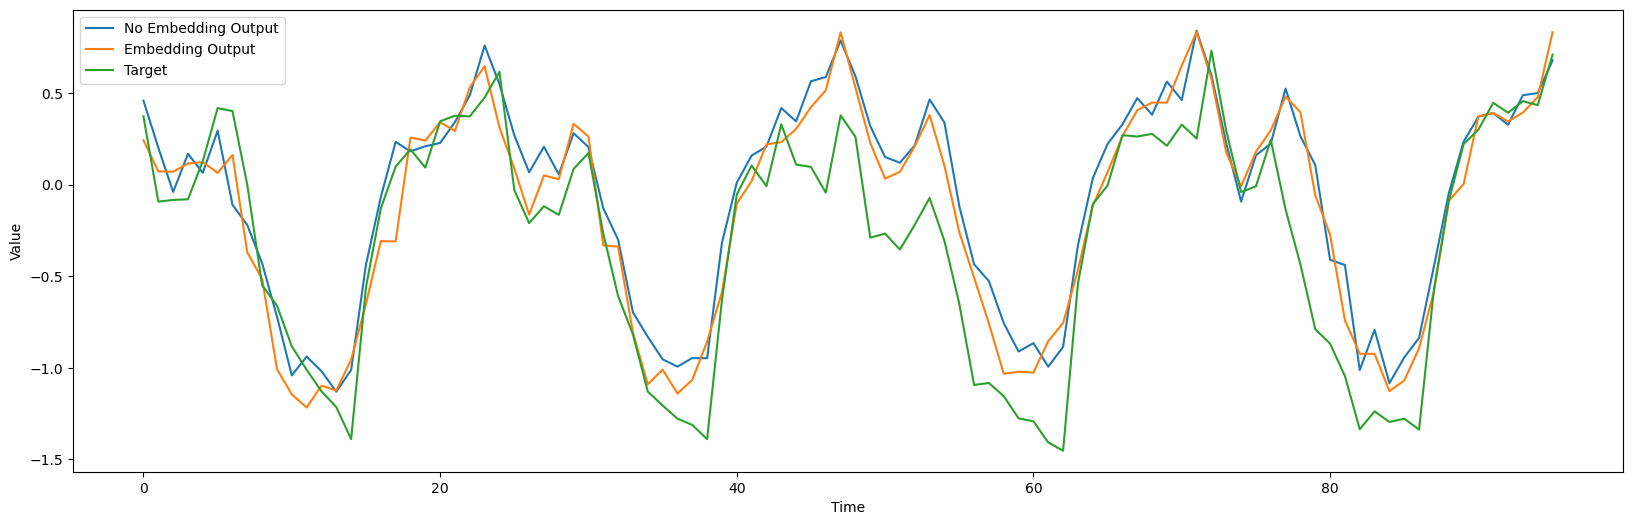

In [32]:
batch = 1
channel = -1
# 在同一张图上画出两个模型的输出以及target
plt.figure()
# 调整图像大小
plt.figure(figsize=(20, 6))
plt.plot(no_embedding_output[batch, :, channel].cpu().detach().numpy().flatten(), label='No Embedding Output')
plt.plot(embedding_output[batch, :, channel].cpu().detach().numpy().flatten(), label='Embedding Output')
plt.plot(target[batch, :, channel].cpu().detach().numpy().flatten(), label='Target')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()